# 0DTE experimental lab (15:30 ATM package)

Same instrument, clocks, smear, and signal as
`atm_straddle_rv_iv.ipynb`. This notebook is the lab for:

1. ensembles of the seven models and of the three paper rules
   (including a causal PCR / spectral ensemble), plus extended causal
   PCA/PCR books (§5b), supervised PLS/PCovR projections (§5c), and
   PCA structure diagnostics (§5d)
2. vol-space maps $\hat y\sqrt{B}$, $m\sqrt{B}$ (stand-in if
   `atm_straddle_volmap.ipynb` is not in the tree)
3. extra weighting rules (rank, inv-vol, dead-zone, vol-target, Kelly-ish)
4. an iron condor lab (§8–§12): width ladder, wing-cost / tail / IR
   diagnostics, strangle bodies with per-side attribution, the §5
   ensembles on the defined-risk instrument, and quoted-spread fill
   sensitivity
5. paired significance (NW + block bootstrap) on the headline deltas
   (§13)

$R \sim a + b\,s$ lives in `atm_straddle_rv_iv.ipynb`.

Published mid-fill rule tables stay in the RV–IV notebook. Intraday
bars stay in `atm_straddle_intraday.ipynb`.

In [1]:
import hashlib
import os
import sys
from pathlib import Path
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import yfinance as yf
import statsmodels.api as sm

sys.path.insert(0, str(Path.cwd() if (Path.cwd() / "atm_straddle_lib.py").exists() else Path.cwd() / "notebooks"))
import atm_straddle_lib as asl

REPO = asl.find_repo(Path.cwd())
sys.path.insert(0, str(REPO / "notebooks"))
import atm_straddle_lib as asl
OUT = REPO / "results" / "atm_straddle_0dte_1530"
OUT.mkdir(parents=True, exist_ok=True)
CACHE = OUT / "cache"
CACHE.mkdir(parents=True, exist_ok=True)
print("repo:", REPO)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 24)
pd.set_option("display.float_format", lambda x: f"{x: .6f}")


repo: C:\Users\james\CC Allowed\harxhar-0dte-professor


## 1. Chain, nearest-OTM package, $R$, forecasts, signal

In [2]:
path = REPO / "data" / "spxw_chain.parquet"
COLS = ["expiration", "timestamp", "strike", "cp", "bid", "ask", "mid", "underlying_price", "impl_volatility"]
_st = os.stat(path)
_ck = CACHE / f"chain_15301600_{_st.st_size}_{_st.st_mtime_ns}.parquet"
if _ck.exists():
    chain = pd.read_parquet(_ck)
else:
    ts = pd.to_datetime(pd.read_parquet(path, columns=["timestamp"])["timestamp"], utc=True)
    et = ts.dt.tz_convert("America/New_York")
    keep = ts[((et.dt.hour == 15) & (et.dt.minute == 30)) | ((et.dt.hour == 16) & (et.dt.minute == 0))].unique()
    chain = pd.read_parquet(path, columns=COLS, filters=[("timestamp", "in", list(keep))])
    chain["timestamp"] = pd.to_datetime(chain["timestamp"], utc=True)
    chain["expiration"] = pd.to_datetime(chain["expiration"])
    chain["cp"] = chain["cp"].astype(str).str.upper().str[0]
    chain.to_parquet(_ck)
codes, uts = pd.factorize(chain["timestamp"])
uet = pd.DatetimeIndex(uts).tz_convert("America/New_York")
chain["et"] = uet.take(codes)
hh = np.where((uet.hour == 15) & (uet.minute == 30), "15:30",
              np.where((uet.hour == 16) & (uet.minute == 0), "16:00", "other"))
chain["hhmm"] = hh[codes]
chain["et_date"] = uet.normalize().take(codes)
ecodes, uexp = pd.factorize(chain["expiration"])
uexp_d = pd.DatetimeIndex(uexp).tz_localize("America/New_York", ambiguous="NaT", nonexistent="NaT").normalize()
chain["exp_date"] = uexp_d.take(ecodes)
chain["is_0dte"] = chain["et_date"] == chain["exp_date"]
book_chain = chain[chain["is_0dte"] & chain["hhmm"].isin(["15:30", "16:00"])].copy()
del chain
e = book_chain[book_chain["hhmm"] == "15:30"].copy()
live = e[np.isfinite(e["mid"]) & (e["mid"] > 0)].copy()
spot = live.dropna(subset=["underlying_price"]).groupby("expiration")["underlying_price"].first()
atm = asl.pick_nearest_otm(live, spot)
atm["day"] = atm["et_c"].dt.tz_convert("America/New_York").dt.normalize().dt.tz_localize(None)

def load_gspc_close(days):
    days = pd.to_datetime(days)
    cp = CACHE / "gspc_close.parquet"
    if cp.exists():
        cached = pd.read_parquet(cp)["close"]
        cached.index = pd.to_datetime(cached.index)
        if cached.index.min() <= pd.Timestamp(days.min()) and cached.index.max() >= pd.Timestamp(days.max()):
            return cached.astype(float)
    raw = yf.download("^GSPC", start=pd.Timestamp(days.min()) - pd.Timedelta("7D"),
                      end=pd.Timestamp(days.max()) + pd.Timedelta("7D"),
                      auto_adjust=True, progress=False, threads=True)
    close = raw["Close"]
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    ix = pd.to_datetime(close.index)
    if getattr(ix, "tz", None) is not None:
        ix = ix.tz_convert("America/New_York").tz_localize(None)
    close.index = ix.normalize()
    close.rename("close").to_frame().to_parquet(cp)
    return close.astype(float)

exp_day = pd.to_datetime(atm["expiration"])
if getattr(exp_day.dt, "tz", None) is not None:
    exp_day = exp_day.dt.tz_convert("America/New_York").dt.tz_localize(None)
exp_day = exp_day.dt.normalize()
atm["S_close"] = exp_day.map(load_gspc_close(exp_day))
atm["pay_c"] = np.maximum(atm["S_close"] - atm["K_c"], 0.0)
atm["pay_p"] = np.maximum(atm["K_p"] - atm["S_close"], 0.0)
atm["exit"] = atm["pay_c"] + atm["pay_p"]
atm = atm[np.isfinite(atm["entry"]) & np.isfinite(atm["exit"]) & (atm["entry"] > 0)].copy()
atm["R"] = atm["exit"] / atm["entry"] - 1.0
atm = atm.set_index("day").sort_index()
atm = asl.attach_iv_hourly_as_30min(atm)

from concurrent.futures import ThreadPoolExecutor
YHATS = asl.yhat_paths(REPO)
need_dates = set(atm.index)
with ThreadPoolExecutor(max_workers=len(YHATS)) as pool:
    futs = {tag: pool.submit(asl.load_yhat_1530_mz_cached, tag, path, need_dates, CACHE)
            for tag, path in YHATS.items()}
    models = {tag: futs[tag].result() for tag in YHATS}
LABEL = asl.YHAT_LABEL
MODEL_ORDER = asl.MODEL_ORDER

books = {}
for tag, rv in models.items():
    px = atm.join(rv[["rv_hat", "yhat", "m", "yhat_vol", "m_vol", "rv_raw", "baseline"]], how="inner")
    px = px.dropna(subset=["R", "rv_hat", "iv_var"])
    px = px[(px["rv_hat"] > 0) & (px["iv_var"] > 0)]
    px["signal"] = px["rv_hat"] - px["iv_var"]
    px["pos"] = np.where(px["signal"] > 0, 1.0, -1.0)
    books[tag] = px
common = None
for tag in MODEL_ORDER:
    common = books[tag].index if common is None else common.intersection(books[tag].index)
common = common.sort_values()
print("common days", len(common), pd.Timestamp(common.min()), "->", pd.Timestamp(common.max()))


common days 871 2020-01-03 00:00:00 -> 2024-04-30 00:00:00


## 5. Ensemble of the seven models

(a) mean $s$ then sign. (b) majority vote of sign. (c) equal-weight
average of unit-median $q$. (d) trailing-Sharpe and trailing-IR
weights on unit-median $q$ (expanding 63, lag 1). (e) causal spectral /
PCR ensemble of the seven signals (below). Also a 50/50 mix of
always-short and unit-median on blk2, and an equal-weight mix of the
three paper rules on blk2.

**Spectral / PCR.** Let $X_t\in\mathbb{R}^7$ be the vector of model
signals $s=\widehat{RV}-\mathrm{IV}_{30}^{2}$ on day $t$. On days
$u<t$ (min 63) center $X$, take the SVD, and read day $t$ onto the
leading $k$ right singular vectors. Two books:

- *spectral PC1:* $s^{\mathrm{pc1}}_t$ is the PC1 score; sign is
  flipped so PC1 co-moves with the cross-sectional mean $s$. Position
  is $\mathrm{sign}(s^{\mathrm{pc1}})$ or unit-median in that score.
- *PCR $k=1,2$:* regress $R_u$ on the lagged PC scores, apply the
  coefficients to day $t$. Position is $\mathrm{sign}(\hat R_t)$.

The SVD and the PCR fit use only $u<t$. Full-sample eigenvalues are
printed as a diagnostic, not used to trade.

full-sample variance share (diagnostic)
PC1    0.922649
PC2    0.046175
PC3    0.023325
PC4    0.005965
PC5    0.001354
PC6    0.000334
PC7    0.000198
full-sample loadings (sign of PC1 aligned to mean s)
                                   PC1       PC2
HAR + calendar OLS            0.129753  0.059250
block-diag ridge              0.389599  0.397444
LightGBM                      0.419871 -0.529165
XGBoost                       0.386522 -0.586040
lasso (causally tuned)        0.407684  0.218714
lasso (fixed 1e-4)            0.392714  0.397820
elastic net (causally tuned)  0.430413  0.094723


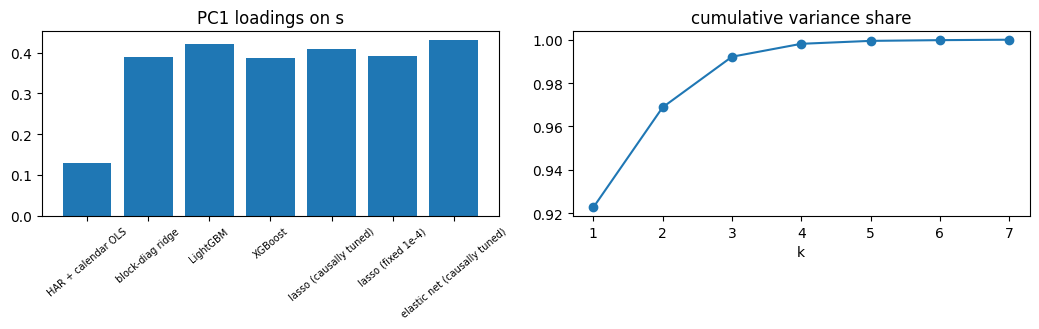

                                   n      mean       std        min       25%       50%       75%        max      skew    ex_kurt    t_mean  Sharpe_ann       n_buy    pct_buy
mean-s then sign          871.000000  0.109613  1.121665  -5.422480 -0.652345  0.161679  0.912365  10.316049  0.994760  10.542220  2.884095    1.551318  478.000000  54.879449
majority vote             871.000000  0.108787  1.121745  -5.422480 -0.650023  0.160026  0.915427  10.316049  0.963060  10.554403  2.862134    1.539505  479.000000  54.994259
EW unit-median q          871.000000  0.110976  1.102530  -5.506694 -0.247156  0.040311  0.493161   6.440987 -0.106394   5.245320  2.970638    1.597868  477.000000  54.764638
trail-Sharpe um q         871.000000  0.112506  1.106537  -5.546840 -0.251549  0.045029  0.492904   5.980162 -0.137741   4.867608  3.000663    1.614018  481.000000  55.223881
trail-IR um q             871.000000  0.111477  1.097339  -5.561180 -0.242124  0.039672  0.490298   5.639393 -0.173609   4.89

In [3]:
sig = pd.DataFrame({tag: books[tag]["signal"].loc[common] for tag in MODEL_ORDER})
pos = np.sign(sig).replace(0.0, -1.0)
R = books["blk2"]["R"].loc[common]
um = pd.DataFrame({tag: asl.rule_sizes(books[tag])["unit-median VRP"].loc[common] for tag in MODEL_ORDER})

ens = {}
ens["mean-s then sign"] = np.sign(sig.mean(axis=1)).replace(0.0, -1.0) * R
ens["majority vote"] = np.sign(pos.sum(axis=1)).replace(0.0, -1.0) * R
ens["EW unit-median q"] = um.mean(axis=1) * R

def trailing_w(q: pd.DataFrame, kind: str) -> pd.Series:
    w_hist = []
    idx = q.index
    out = pd.Series(0.0, index=idx)
    for i, t in enumerate(idx):
        if i < 63:
            w = np.ones(q.shape[1]) / q.shape[1]
        else:
            sl = slice(0, i)
            scores = []
            for col in q.columns:
                rp = (q[col] * R).iloc[sl]
                mu, sd = float(rp.mean()), float(rp.std(ddof=1))
                if kind == "sharpe":
                    scores.append(mu / sd if sd > 0 else 0.0)
                else:
                    active = rp - (-R.iloc[sl])
                    a_sd = float(active.std(ddof=1))
                    scores.append(float(active.mean()) / a_sd if a_sd > 0 else 0.0)
            w = np.maximum(np.array(scores, float), 0.0)
            w = w / w.sum() if w.sum() > 0 else np.ones_like(w) / len(w)
        out.iloc[i] = float((q.iloc[i] * w).sum())
    return out

ens["trail-Sharpe um q"] = trailing_w(um, "sharpe") * R
ens["trail-IR um q"] = trailing_w(um, "ir") * R
blk_sizes = asl.rule_sizes(books["blk2"])
ens["blk2 0.5 AS + 0.5 UM"] = (0.5 * blk_sizes["always short"] + 0.5 * blk_sizes["unit-median VRP"]).loc[common] * R
ens["blk2 EW 3 rules"] = (
    blk_sizes["always short"] + blk_sizes["long-short volatility"] + blk_sizes["unit-median VRP"]
).loc[common] / 3.0 * R
ens["blk2 unit-median (bench)"] = blk_sizes["unit-median VRP"].loc[common] * R
ens["blk2 long-short"] = blk_sizes["long-short volatility"].loc[common] * R
ens["always short"] = blk_sizes["always short"].loc[common] * R

# Causal spectral / PCR ensemble of the 7-vector of signals.
# Day t sees only X[:t] (strict). Min 63 days; earlier days sit at EW sign.
X = sig.to_numpy(float)
r = R.to_numpy(float)
n, p = X.shape
s_pc1 = np.full(n, np.nan)
rhat_k1 = np.full(n, np.nan)
rhat_k2 = np.full(n, np.nan)
loadings_last = None
for t in range(n):
    if t < 63:
        s_pc1[t] = float(X[t].mean())
        rhat_k1[t] = s_pc1[t]
        rhat_k2[t] = s_pc1[t]
        continue
    past = X[:t]
    mu = past.mean(axis=0)
    Xc = past - mu
    # economy SVD on T x 7
    _, S_sing, Vt = np.linalg.svd(Xc, full_matrices=False)
    v1 = Vt[0]
    if np.dot(v1, np.ones(p)) < 0:
        v1 = -v1
        Vt = Vt.copy()
        Vt[0] = v1
    xt = X[t] - mu
    z1 = float(xt @ Vt[0])
    z2 = float(xt @ Vt[1])
    s_pc1[t] = z1
    Z1 = Xc @ Vt[0]
    Z2 = np.column_stack([Z1, Xc @ Vt[1]])
    y = r[:t]
    def ols_apply(Z, y, znew):
        Z1c = np.column_stack([np.ones(len(y)), Z])
        beta, *_ = np.linalg.lstsq(Z1c, y, rcond=None)
        z = np.concatenate([[1.0], np.atleast_1d(znew)])
        return float(z @ beta)
    rhat_k1[t] = ols_apply(Z1, y, z1)
    rhat_k2[t] = ols_apply(Z2, y, [z1, z2])
    loadings_last = (S_sing, Vt)

s_pc1 = pd.Series(s_pc1, index=sig.index)
rhat_k1 = pd.Series(rhat_k1, index=sig.index)
rhat_k2 = pd.Series(rhat_k2, index=sig.index)
q_pc1 = np.sign(s_pc1).replace(0.0, -1.0)
q_pcr1 = np.sign(rhat_k1).replace(0.0, -1.0)
q_pcr2 = np.sign(rhat_k2).replace(0.0, -1.0)
q_pc1_um = q_pc1 * asl.causal_leverage(s_pc1)
ens["spectral PC1 sign"] = q_pc1 * R
ens["spectral PC1 unit-median"] = q_pc1_um * R
ens["PCR k=1 sign"] = q_pcr1 * R
ens["PCR k=2 sign"] = q_pcr2 * R

# Full-sample SVD diagnostic only (not a trading input).
Xc_all = X - X.mean(axis=0)
_, S_all, Vt_all = np.linalg.svd(Xc_all, full_matrices=False)
share = S_all**2 / (S_all**2).sum()
load_tab = pd.DataFrame(Vt_all[:2].T, index=[LABEL[t] for t in MODEL_ORDER], columns=["PC1", "PC2"])
if np.dot(load_tab["PC1"], np.ones(p)) < 0:
    load_tab["PC1"] *= -1
print("full-sample variance share (diagnostic)")
print(pd.Series(share, index=[f"PC{i+1}" for i in range(p)]).to_string())
print("full-sample loadings (sign of PC1 aligned to mean s)")
print(load_tab.to_string())
load_tab.to_csv(OUT / "ensemble_spectral_loadings.csv")
pd.Series(share, index=[f"PC{i+1}" for i in range(p)]).to_csv(OUT / "ensemble_spectral_varshare.csv")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.4))
axes[0].bar(load_tab.index, load_tab["PC1"].to_numpy())
axes[0].set_title("PC1 loadings on s")
axes[0].tick_params(axis="x", rotation=40, labelsize=7)
axes[1].plot(np.arange(1, p + 1), share.cumsum(), marker="o")
axes[1].set_title("cumulative variance share")
axes[1].set_xlabel("k")
fig.tight_layout()
fig.savefig(OUT / "ensemble_spectral_pca.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)

ens_tab = pd.DataFrame({k: asl.rule_row(v, np.sign(v).replace(0, -1)) for k, v in ens.items()}).T
print(ens_tab.to_string())
ens_tab.to_csv(OUT / "ensemble_summary.csv")
pd.DataFrame(ens).to_csv(OUT / "ensemble_daily.csv")
print("saved ensemble_*.csv")


## 5b. Causal PCA/PCR books — where the ensemble information lives

Extensions of the §5 spectral machinery, same protocol throughout: day
$t$ uses the SVD of the centered signal matrix on days $u<t$ only
(min 63; earlier days sit at the EW mean-signal fallback), and PC1's
sign co-moves with the cross-sectional mean $s$. Nothing here is a
search for a better rule — the table maps where the ensemble
information lives.

- *PCR $k$-sweep:* regress $R_u$ on the first $k$ lagged PC scores,
  $k=1,\dots,7$, apply the coefficients to day $t$, trade
  $\mathrm{sign}(\hat R_t)$. Fitted values are invariant to component
  sign flips, so the sweep needs no convention beyond PC1's.
- *PC2 / PC3 sign books:* $q_t=\mathrm{sign}(\hat\beta_{j,t})\,
  \mathrm{sign}(z_{j,t})$, where $\hat\beta_{j,t}$ is the OLS slope of
  $R_u$ on the past PC$_j$ scores — the sign convention is itself
  estimated only from $u<t$.
- *PCR $k{=}1$ unit-median:* unit-median leverage in the fitted value
  $\hat R$ (expanding median of $|\hat R|$, lag 1, cap 3).
- *PC1-of-$q$:* the same causal PC1 taken on the 7-vector of signed
  unit-median positions $q$ instead of raw $s$; trade the sign of the
  score.

Benchmarks repeat from §5. The first four rows reproduce the §5 books
exactly; the in-cell check prints the max $|R'|$ discrepancy against
`ens`.

In [4]:
X = sig.to_numpy(float)
r = R.to_numpy(float)
n, p = X.shape
scores = np.full((n, p), np.nan)
bsign = np.ones((n, p))
rhat_k = {k: np.full(n, np.nan) for k in range(1, p + 1)}
for t in range(n):
    if t < 63:
        ew = float(X[t].mean())
        scores[t, :] = ew
        for k in rhat_k:
            rhat_k[k][t] = ew
        continue
    past = X[:t]
    mu = past.mean(axis=0)
    Xc = past - mu
    _, _, Vt = np.linalg.svd(Xc, full_matrices=False)
    if np.dot(Vt[0], np.ones(p)) < 0:
        Vt = Vt.copy()
        Vt[0] = -Vt[0]
    xt = X[t] - mu
    z = xt @ Vt.T
    Z = Xc @ Vt.T
    scores[t] = z
    y = r[:t]
    for j in range(p):
        bsign[t, j] = 1.0 if float(Z[:, j] @ y) >= 0 else -1.0
    ones = np.ones((t, 1))
    for k in range(1, p + 1):
        Zk = np.column_stack([ones, Z[:, :k]])
        beta, *_ = np.linalg.lstsq(Zk, y, rcond=None)
        rhat_k[k][t] = float(np.concatenate([[1.0], z[:k]]) @ beta)

idx = sig.index
s_pc1x = pd.Series(scores[:, 0], index=idx)
rhat = {k: pd.Series(v, index=idx) for k, v in rhat_k.items()}


def _sgn(x):
    return np.sign(x).replace(0.0, -1.0)


pca_books = {}
q1 = _sgn(s_pc1x)
pca_books["spectral PC1 sign"] = q1 * R
pca_books["spectral PC1 unit-median"] = q1 * asl.causal_leverage(s_pc1x) * R
for k in range(1, p + 1):
    pca_books[f"PCR k={k} sign"] = _sgn(rhat[k]) * R
pca_books["PCR k=1 unit-median"] = _sgn(rhat[1]) * asl.causal_leverage(rhat[1]) * R
for j in (1, 2):
    zj = pd.Series(scores[:, j] * bsign[:, j], index=idx)
    pca_books[f"PC{j+1} sign (beta-aligned)"] = _sgn(zj) * R

# Causal PC1 on the 7-vector of signed unit-median positions q.
Xq = um.to_numpy(float)
s_q1 = np.full(n, np.nan)
for t in range(n):
    if t < 63:
        s_q1[t] = float(Xq[t].mean())
        continue
    past = Xq[:t]
    mu = past.mean(axis=0)
    Xc = past - mu
    _, _, Vt = np.linalg.svd(Xc, full_matrices=False)
    v1 = Vt[0] if np.dot(Vt[0], np.ones(p)) >= 0 else -Vt[0]
    s_q1[t] = float((Xq[t] - mu) @ v1)
s_q1 = pd.Series(s_q1, index=idx)
pca_books["PC1-of-q sign"] = _sgn(s_q1) * R

pca_books["EW unit-median q"] = ens["EW unit-median q"]
pca_books["blk2 unit-median (bench)"] = ens["blk2 unit-median (bench)"]
pca_books["always short"] = ens["always short"]

chk = max(
    float((pca_books[k_] - ens[k_]).abs().max())
    for k_ in ("spectral PC1 sign", "spectral PC1 unit-median",
               "PCR k=1 sign", "PCR k=2 sign")
)
print("max |R' diff| vs the §5 books:", chk)
pca_tab = pd.DataFrame({k: asl.rule_row(v, _sgn(v)) for k, v in pca_books.items()}).T
print(pca_tab.to_string())
pca_tab.to_csv(OUT / "pca_lab_books.csv")
print("saved", OUT / "pca_lab_books.csv")


max |R' diff| vs the §5 books: 8.881784197001252e-16
                                   n      mean       std        min       25%       50%       75%        max      skew    ex_kurt    t_mean  Sharpe_ann       n_buy    pct_buy
spectral PC1 sign         871.000000  0.083094  1.123943 -10.316049 -0.489474  0.268846  0.932559   6.836034 -1.324720  11.237965  2.181889    1.173610  514.000000  59.012629
spectral PC1 unit-median  871.000000  0.033988  0.899238  -6.124124 -0.143283  0.044021  0.375430   6.836034 -0.777301  11.853711  1.115480    0.600003  514.000000  59.012629
PCR k=1 sign              871.000000 -0.028898  1.126643 -10.316049 -0.754070  0.056846  0.819001   6.836034 -1.138689  10.623474 -0.756985   -0.407172  447.000000  51.320321
PCR k=2 sign              871.000000 -0.006286  1.126996 -10.316049 -0.729437  0.110074  0.837196   6.836034 -1.140620  10.701817 -0.164603   -0.088538  464.000000  53.272101
PCR k=3 sign              871.000000 -0.006712  1.126994 -10.316049 -0.7

## 5c. Causal supervised projections (PLS / PCovR)

Section 5's PC1/PCR books are unsupervised: the direction is chosen by
the variance of the seven signals, and $R$ enters only through the PCR
coefficients. Here the *direction itself* is supervised, with the same
strict causality as §5 (day $t$ uses $X_{u<t}$, $R_{u<t}$ only; min 63;
earlier days sit at the EW-mean score). Nothing here is a search for a
better rule — it maps whether supervision adds anything over PC1. The
lab's standing result is that ensembles do not beat blk2 unit-median,
so a null is the expected answer.

- *PLS1:* $w\propto X_c^{\top}R_c$ (the covariance-with-target
  direction), $\|w\|=1$; score $z_t=(x_t-\mu)^{\top}w$. Books:
  $\mathrm{sign}(z)$ and unit-median in $z$.
- *PLS2:* one NIPALS deflation ($X_c^{(2)}=X_c-t_1p_1^{\top}$,
  $w_2\propto X_c^{(2)\top}R_c$), then OLS of $R$ on $[z_1,z_2]$ with
  intercept, applied to day $t$ — the supervised analog of PCR $k=2$.
  Book: $\mathrm{sign}(\hat R_t)$.
- *PCovR blend:* leading eigenvector of
  $\alpha\,G_1/\mathrm{tr}\,G_1+(1-\alpha)\,G_2/\mathrm{tr}\,G_2$ with
  $G_1=(X_c^{\top}R_c)(X_c^{\top}R_c)^{\top}$, $G_2=X_c^{\top}X_c$,
  $\alpha\in\{0.25,0.5,0.75\}$; each Gram is normalized by its trace so
  the mix is scale-free. Sign aligned so the score co-moves with the
  PLS1 direction. Book: $\mathrm{sign}(z)$.

Columns as in §5's ensemble table (`asl.rule_row`; daily book,
$\sqrt{252}$). Benchmarks are pulled from §5's `ens` dict, not
recomputed.

In [5]:
PLS_ALPHAS = (0.25, 0.5, 0.75)
z_pls1 = np.full(n, np.nan)
rhat_pls2 = np.full(n, np.nan)
z_pcovr = {a: np.full(n, np.nan) for a in PLS_ALPHAS}

def _ols_apply(Z, y, znew):
    Z1c = np.column_stack([np.ones(len(y)), Z])
    beta, *_ = np.linalg.lstsq(Z1c, y, rcond=None)
    z = np.concatenate([[1.0], np.atleast_1d(znew)])
    return float(z @ beta)

for t in range(n):
    if t < 63:
        ew = float(X[t].mean())
        z_pls1[t] = ew
        rhat_pls2[t] = ew
        for a in PLS_ALPHAS:
            z_pcovr[a][t] = ew
        continue
    past = X[:t]
    mu = past.mean(axis=0)
    Xc = past - mu
    y = r[:t]
    yc = y - y.mean()
    xt = X[t] - mu

    # PLS1: covariance-with-target direction, unit norm.
    w1 = Xc.T @ yc
    nw = float(np.linalg.norm(w1))
    w1 = np.ones(p) / np.sqrt(p) if nw == 0 else w1 / nw
    z1 = float(xt @ w1)
    z_pls1[t] = z1

    # PLS2: one NIPALS deflation, then OLS of R on [z1, z2] with intercept.
    T1 = Xc @ w1
    tt = float(T1 @ T1)
    p1 = Xc.T @ T1 / tt if tt > 0 else np.zeros(p)
    Xc2 = Xc - np.outer(T1, p1)
    w2 = Xc2.T @ yc
    nw2 = float(np.linalg.norm(w2))
    w2 = np.zeros(p) if nw2 == 0 else w2 / nw2
    z2 = float((xt - float(xt @ w1) * p1) @ w2)
    rhat_pls2[t] = _ols_apply(np.column_stack([T1, Xc2 @ w2]), y, [z1, z2])

    # PCovR blend: leading eigenvector of the trace-normalized Gram mix.
    g = Xc.T @ yc
    G1 = np.outer(g, g)
    G2 = Xc.T @ Xc
    tr1, tr2 = float(np.trace(G1)), float(np.trace(G2))
    for a in PLS_ALPHAS:
        M = np.zeros((p, p))
        if tr1 > 0:
            M = M + a * G1 / tr1
        if tr2 > 0:
            M = M + (1.0 - a) * G2 / tr2
        _, vecs = np.linalg.eigh(M)
        v = vecs[:, -1]
        ref = g if float(np.linalg.norm(g)) > 0 else np.ones(p)
        if float(v @ ref) < 0:
            v = -v
        z_pcovr[a][t] = float(xt @ v)

z_pls1 = pd.Series(z_pls1, index=sig.index)
rhat_pls2 = pd.Series(rhat_pls2, index=sig.index)

sup = {}
q_pls1 = np.sign(z_pls1).replace(0.0, -1.0)
sup["PLS1 sign"] = q_pls1 * R
sup["PLS1 unit-median"] = q_pls1 * asl.causal_leverage(z_pls1) * R
sup["PLS2 rhat sign"] = np.sign(rhat_pls2).replace(0.0, -1.0) * R
for a in PLS_ALPHAS:
    za = pd.Series(z_pcovr[a], index=sig.index)
    sup[f"PCovR a={a} sign"] = np.sign(za).replace(0.0, -1.0) * R
for k in ("PCR k=1 sign", "spectral PC1 sign", "EW unit-median q",
          "blk2 unit-median (bench)", "always short"):
    sup[k] = ens[k]

pls_tab = pd.DataFrame({k: asl.rule_row(v, np.sign(v).replace(0, -1)) for k, v in sup.items()}).T
print(pls_tab.to_string())
pls_tab.to_csv(OUT / "pca_lab_pls.csv")
n_flip = int((np.sign(pd.Series(z_pcovr[0.25], index=sig.index))
              != np.sign(pd.Series(z_pcovr[0.75], index=sig.index))).sum())
print("PCovR sign flips between a=0.25 and a=0.75:", n_flip)
print("saved", OUT / "pca_lab_pls.csv")


                                   n      mean       std        min       25%       50%       75%        max      skew    ex_kurt    t_mean  Sharpe_ann       n_buy    pct_buy
PLS1 sign                 871.000000  0.006414  1.126996 -10.316049 -0.645985  0.163874  0.880598   6.836034 -1.334045  10.757918  0.167969    0.090348  481.000000  55.223881
PLS1 unit-median          871.000000  0.037305  1.220574 -10.622293 -0.353850  0.069876  0.530741  10.652714 -0.357503  16.960051  0.902002    0.485176  481.000000  55.223881
PLS2 rhat sign            871.000000 -0.011311  1.126957 -10.316049 -0.737386  0.099442  0.829974   6.836034 -1.129317  10.683329 -0.296199   -0.159322  460.000000  52.812859
PCovR a=0.25 sign         871.000000  0.007638  1.126988 -10.316049 -0.787543  0.002267  0.798172   6.836034 -0.730301  10.747589  0.200031    0.107594  436.000000  50.057405
PCovR a=0.5 sign          871.000000  0.006732  1.126994 -10.316049 -0.745648  0.055724  0.821556   6.836034 -0.855496  10.74

## 5d. PCA structure diagnostics

How much structure is there in the seven signals, and how many
independent bets are the seven books? **Diagnostics only — nothing
here is a trading input.** Six views:

- *Correlation / sign agreement.* Pearson correlation of the daily
  $s$ vectors and pairwise sign-agreement %. Answers: how far from
  one signal are the seven models?
- *Expanding causal PC1 share.* At each $t\ge 63$, PC1 variance share
  of the SVD of $X_{u<t}$ — the factor strength a day-$t$ trader
  would have seen. Answers: does the one-factor structure
  strengthen or decay?
- *Loading stability.* PC1 loadings at expanding cutoffs
  (every 21 days). Answers: does any model rotate in or out of the
  factor?
- *Risk-space PCA.* Full-sample PCA of the seven unit-median book
  returns $q_i R$. Answers: how many independent bets are the seven
  books in return space?
- *PC1 vs mean.* Full-sample PC1 score against the cross-sectional
  mean $s$. Answers: is PC1 anything other than the equal-weight
  mean?
- *$R^2$ ladder.* Full-sample $R^2$ of daily $R$ on the first $k$ PC
  scores, $k=1..7$ — the in-sample ceiling for the causal PCR books
  of §5.

Pearson correlation of daily signals s (diagnostic)
               a0      blk2      lgbm       xgb   lasso_t   lasso_f      enet
a0       1.000000  0.756577  0.661551  0.687973  0.624824  0.738351  0.640984
blk2     0.756577  1.000000  0.866614  0.851659  0.945583  0.996922  0.935738
lgbm     0.661551  0.866614  1.000000  0.991010  0.908918  0.873951  0.934937
xgb      0.687973  0.851659  0.991010  1.000000  0.870153  0.852366  0.895543
lasso_t  0.624824  0.945583  0.908918  0.870153  1.000000  0.960637  0.989653
lasso_f  0.738351  0.996922  0.873951  0.852366  0.960637  1.000000  0.952151
enet     0.640984  0.935738  0.934937  0.895543  0.989653  0.952151  1.000000
pairwise sign-agreement % (diagnostic)
                 a0        blk2        lgbm         xgb     lasso_t     lasso_f        enet
a0       100.000000   83.352468   87.600459   88.404133   85.763490   81.974742   85.648680
blk2      83.352468  100.000000   81.974742   80.711825   88.633754   94.489093   88.518944
lgbm     

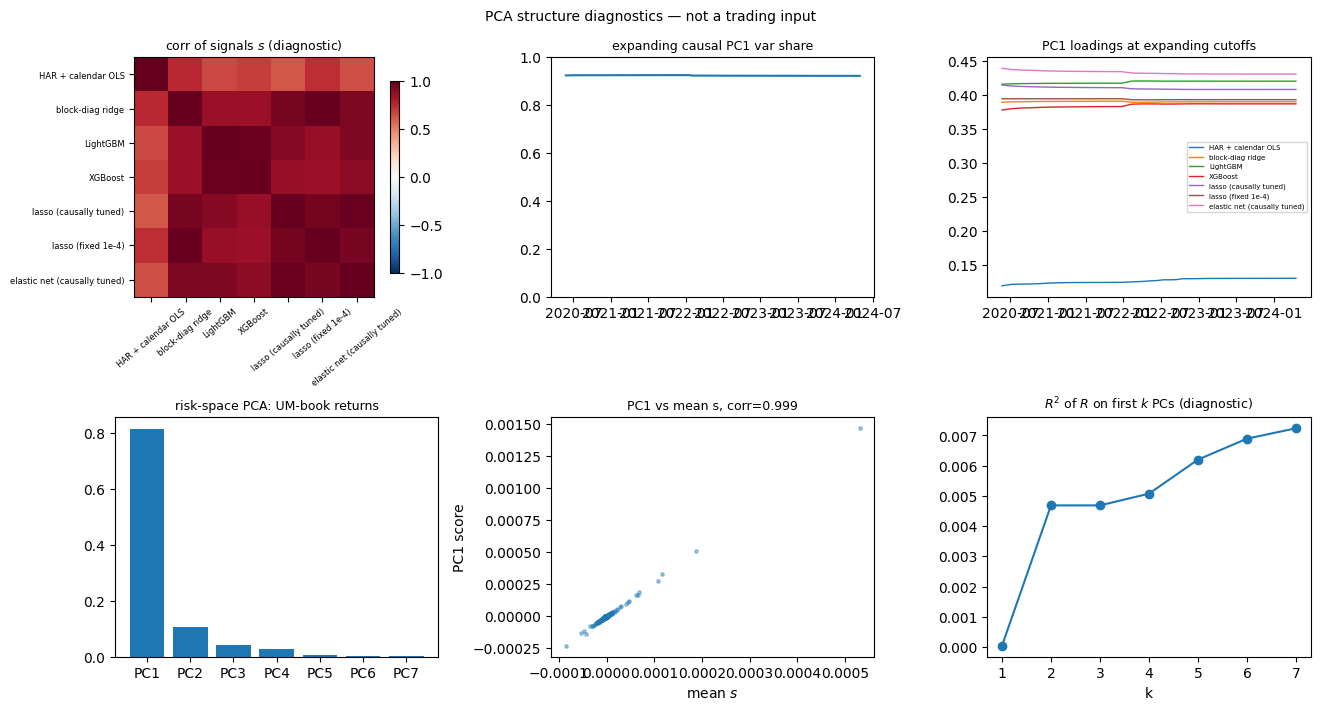

saved pca_lab_structure.png + pca_lab_*.csv


In [6]:
n, p = X.shape
names = [LABEL[t] for t in MODEL_ORDER]

corr = sig.corr()
pos_d = np.sign(sig).replace(0.0, -1.0)
agree = pd.DataFrame(
    {ci: {cj: float((pos_d[ci] == pos_d[cj]).mean() * 100.0) for cj in MODEL_ORDER} for ci in MODEL_ORDER}
).T.loc[MODEL_ORDER, MODEL_ORDER]
print("Pearson correlation of daily signals s (diagnostic)")
print(corr.to_string())
print("pairwise sign-agreement % (diagnostic)")
print(agree.to_string())
corr.to_csv(OUT / "pca_lab_sig_corr.csv")
agree.to_csv(OUT / "pca_lab_sign_agree.csv")

# expanding causal PC1 variance share: what a day-t trader would have seen
share_ts = np.full(n, np.nan)
for t in range(63, n):
    past = X[:t]
    Xc = past - past.mean(axis=0)
    s_sing = np.linalg.svd(Xc, compute_uv=False)
    share_ts[t] = float(s_sing[0] ** 2 / (s_sing**2).sum())
share_ts = pd.Series(share_ts, index=sig.index, name="pc1_share")
print("expanding causal PC1 share: first %.4f last %.4f min %.4f max %.4f"
      % (share_ts.dropna().iloc[0], share_ts.dropna().iloc[-1], share_ts.min(), share_ts.max()))
share_ts.to_csv(OUT / "pca_lab_pc1_share_ts.csv")

# PC1 loadings at expanding cutoffs (~monthly), sign aligned to the mean
traj_rows = {}
for c in range(63, n + 1, 21):
    past = X[:c]
    Xc = past - past.mean(axis=0)
    _, _, Vt = np.linalg.svd(Xc, full_matrices=False)
    v1 = Vt[0] if np.dot(Vt[0], np.ones(p)) >= 0 else -Vt[0]
    traj_rows[sig.index[c - 1]] = v1
traj = pd.DataFrame(traj_rows, index=MODEL_ORDER).T
print("PC1 loading range over expanding cutoffs")
print(pd.DataFrame({"min": traj.min(), "max": traj.max()}).to_string())
traj.to_csv(OUT / "pca_lab_loadings_traj.csv")

# risk-space PCA: how many independent bets are the 7 UM books?
rets = um.mul(R, axis=0)
Rc = rets.to_numpy(float)
Rc = Rc - Rc.mean(axis=0)
s_r = np.linalg.svd(Rc, compute_uv=False)
share_risk = pd.Series(s_r**2 / (s_r**2).sum(), index=[f"PC{i+1}" for i in range(p)])
print("risk-space PCA variance share (7 UM-book daily returns, diagnostic)")
print(share_risk.to_string())
share_risk.to_csv(OUT / "pca_lab_riskspace_share.csv")

# full-sample PC1 vs mean s, and the R^2 ladder
Xc_f = X - X.mean(axis=0)
_, S_f, Vt_f = np.linalg.svd(Xc_f, full_matrices=False)
if np.dot(Vt_f[0], np.ones(p)) < 0:
    Vt_f = Vt_f.copy()
    Vt_f[0] = -Vt_f[0]
z1 = Xc_f @ Vt_f[0]
mean_s = sig.mean(axis=1).to_numpy()
corr_pc1_mean = float(np.corrcoef(z1, mean_s)[0, 1])
print(f"corr(full-sample PC1 score, mean s) = {corr_pc1_mean:.4f}")

y = R.to_numpy(float)
sst = float(((y - y.mean()) ** 2).sum())
r2 = {}
for k in range(1, p + 1):
    Z1 = np.column_stack([np.ones(n), Xc_f @ Vt_f[:k].T])
    beta, *_ = np.linalg.lstsq(Z1, y, rcond=None)
    r2[k] = 1.0 - float(((y - Z1 @ beta) ** 2).sum()) / sst
r2 = pd.Series(r2, name="R2")
print("full-sample R^2 of daily R on first k PC scores (diagnostic ceiling)")
print(r2.to_string())
r2.to_csv(OUT / "pca_lab_r2_ladder.csv")

fig, axes = plt.subplots(2, 3, figsize=(13.5, 7.2))
ax = axes[0, 0]
im = ax.imshow(corr.to_numpy(), vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(p), names, rotation=40, fontsize=6)
ax.set_yticks(range(p), names, fontsize=6)
ax.set_title("corr of signals $s$ (diagnostic)", fontsize=9)
fig.colorbar(im, ax=ax, shrink=0.8)
ax = axes[0, 1]
ax.plot(share_ts.index, share_ts.to_numpy())
ax.set_title("expanding causal PC1 var share", fontsize=9)
ax.set_ylim(0, 1)
ax = axes[0, 2]
for tag in MODEL_ORDER:
    ax.plot(traj.index, traj[tag], label=LABEL[tag], lw=1)
ax.set_title("PC1 loadings at expanding cutoffs", fontsize=9)
ax.legend(fontsize=5)
ax = axes[1, 0]
ax.bar(share_risk.index, share_risk.to_numpy())
ax.set_title("risk-space PCA: UM-book returns", fontsize=9)
ax = axes[1, 1]
ax.scatter(mean_s, z1, s=6, alpha=0.4)
ax.set_xlabel("mean $s$")
ax.set_ylabel("PC1 score")
ax.set_title(f"PC1 vs mean s, corr={corr_pc1_mean:.3f}", fontsize=9)
ax = axes[1, 2]
ax.plot(r2.index, r2.to_numpy(), marker="o")
ax.set_xlabel("k")
ax.set_title("$R^2$ of $R$ on first $k$ PCs (diagnostic)", fontsize=9)
fig.suptitle("PCA structure diagnostics — not a trading input", fontsize=10)
fig.tight_layout()
fig.savefig(OUT / "pca_lab_structure.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)
print("saved pca_lab_structure.png + pca_lab_*.csv")


## 6. Vol-space maps

Stand-in for `atm_straddle_volmap.ipynb`: $\hat y\sqrt{B}$ and
$m\sqrt{B}$ against $\mathrm{IV}_{30}$ and $\sqrt{\mathrm{rv\_raw}}$.

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\volmap_a0_blk2.png


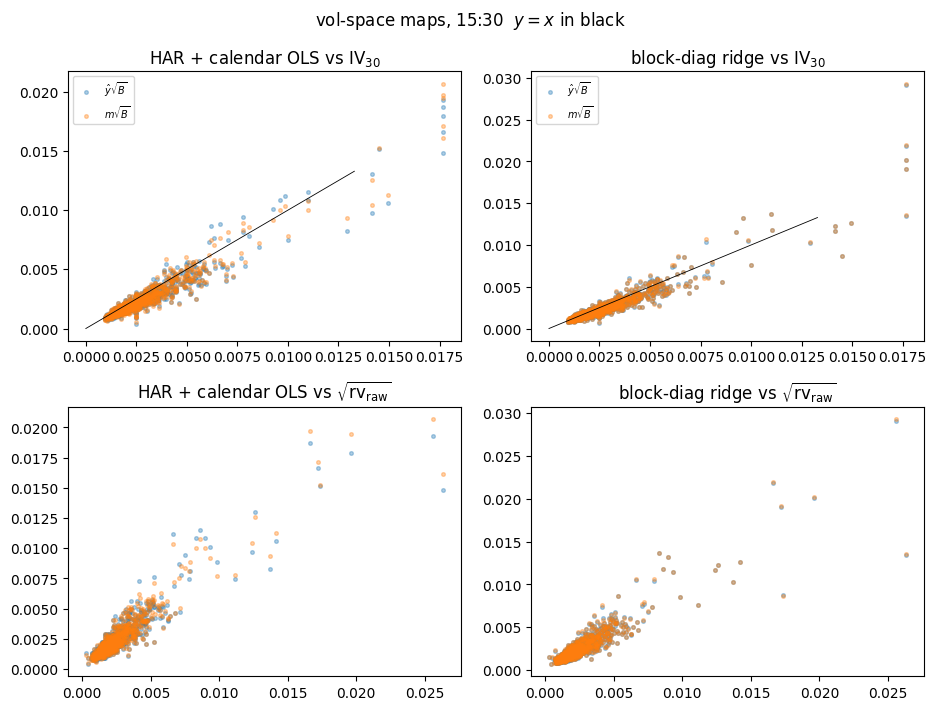

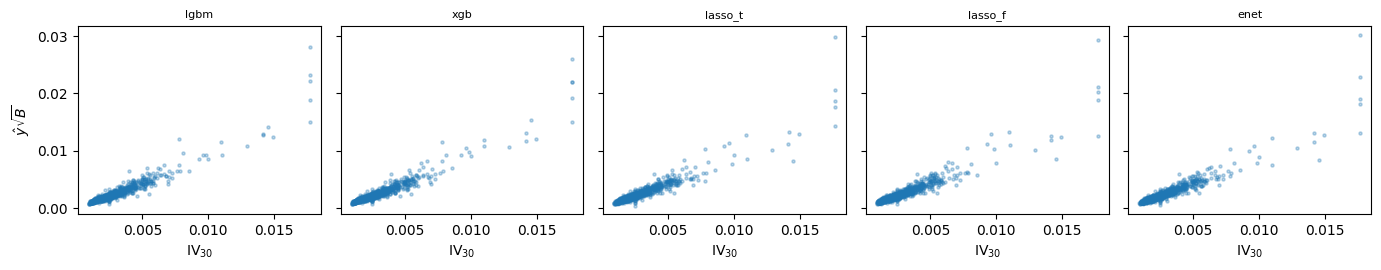

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(9.5, 7.2))
for col, tag in enumerate(("a0", "blk2")):
    px = books[tag].loc[common]
    axes[0, col].scatter(px["iv_30"], px["yhat_vol"], s=7, alpha=0.35, label=r"$\hat y\sqrt{B}$")
    axes[0, col].scatter(px["iv_30"], px["m_vol"], s=7, alpha=0.35, label=r"$m\sqrt{B}$")
    axes[0, col].set_title(LABEL[tag] + r" vs $\mathrm{IV}_{30}$")
    axes[0, col].legend(fontsize=7)
    axes[1, col].scatter(np.sqrt(px["rv_raw"].clip(lower=0)), px["yhat_vol"], s=7, alpha=0.35)
    axes[1, col].scatter(np.sqrt(px["rv_raw"].clip(lower=0)), px["m_vol"], s=7, alpha=0.35)
    axes[1, col].set_title(LABEL[tag] + r" vs $\sqrt{\mathrm{rv_{raw}}}$")
    lo, hi = 0, float(np.nanpercentile(px["iv_30"], 99))
    axes[0, col].plot([lo, hi], [lo, hi], color="k", lw=0.6)
fig.suptitle(r"vol-space maps, 15:30  $y=x$ in black")
fig.tight_layout()
fig.savefig(OUT / "volmap_a0_blk2.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "volmap_a0_blk2.png")
display(fig)
plt.close(fig)

fig, axes = plt.subplots(1, 5, figsize=(14, 2.8), sharey=True)
for ax, tag in zip(axes, ("lgbm", "xgb", "lasso_t", "lasso_f", "enet")):
    px = books[tag].loc[common]
    ax.scatter(px["iv_30"], px["yhat_vol"], s=5, alpha=0.3)
    ax.set_title(tag, fontsize=8)
    ax.set_xlabel(r"$\mathrm{IV}_{30}$")
axes[0].set_ylabel(r"$\hat y\sqrt{B}$")
fig.tight_layout()
fig.savefig(OUT / "volmap_yhat_vs_iv_rest.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)


## 7. Other well-motivated weighting strategies

Rank of $|s|$, inverse expanding vol of $R$, dead-zone at half the
expanding median, vol-target of the unit-median book, and a Kelly-ish
$q=\mathrm{clip}(s/\widehat{\mathrm{Var}}(R),-3,3)$. Scored on the
common days. blk2 shown; CSVs for every model.

In [8]:
extra_names = ["rank-|s|", "inv-vol of R", "dead-zone 0.5 med",
               "vol-target unit-median", "kelly-ish s/var(R)"]
for tag in MODEL_ORDER:
    px = books[tag]
    sizes = asl.extra_weight_sizes(px)
    tab = pd.DataFrame({
        name: asl.rule_row((sizes[name] * px["R"]).loc[common], sizes[name].loc[common])
        for name in extra_names + ["unit-median VRP", "always short"]
    }).T
    tab.to_csv(OUT / f"experimental_weights_{tag}.csv")
    if tag == "blk2":
        print("blk2 extra weights")
        print(tab.to_string())
print("saved experimental_weights_*.csv")


blk2 extra weights
                                 n      mean       std        min       25%       50%       75%        max      skew    ex_kurt    t_mean  Sharpe_ann       n_buy    pct_buy
rank-|s|                871.000000  0.073213  1.060501  -6.005754 -0.119973  0.000000  0.393044   6.836034  0.122769   8.405007  2.037460    1.095924  226.000000  25.947187
inv-vol of R            871.000000  0.114914  1.118989  -5.490101 -0.668194  0.152892  0.881076  10.399342  0.985359  11.037217  3.030805    1.630231  339.000000  38.920781
dead-zone 0.5 med       871.000000  0.059074  0.693408  -3.550905  0.000000  0.000000  0.284820   4.254864  0.011073   5.837456  2.514302    1.352411  140.000000  16.073479
vol-target unit-median  871.000000  0.093894  1.006777  -7.907255 -0.177053  0.010880  0.389763   7.094713 -0.347579  10.591333  2.752417    1.480490  296.000000  33.983927
kelly-ish s/var(R)      871.000000  0.000000  0.000003  -0.000029 -0.000000  0.000000  0.000001   0.000023 -1.417522

saved experimental_weights_*.csv


## 8. Iron condor lab: width ladder

Body is the §1 nearest-OTM package; wings are the nearest live 15:30
mids at least $w$ points further OTM (`asl.pick_wings`, conventions of
the RV–IV notebook §16). Short iron condor = short body + long wings.
Defined-risk long-package return is
$R_{\mathrm{long,ic}}=(\mathrm{exit}_{ic}-\mathrm{entry}_{ic})/\mathrm{width}$,
so the paper's $q$ rules apply unchanged; the three rules use the blk2
signal. Credit-denominator $R$ stays a warning only
(`frac_entry_ic_le0` is the fraction of days with net credit
$\le 0$).

Two width families:

- *fixed:* $w\in\{10,25,50,75,100\}$ points.
- *vol-scaled:* $w = c\cdot\mathrm{entry}_{\mathrm{body}}$,
  $c\in\{1,2,4\}$. The package price is the natural vol-dollar unit
  (it is the market's expected move to the close), so wings sit at a
  roughly constant moneyness-in-vol instead of a constant point
  distance. Bounded by construction: $\mathrm{entry}>0$ on every
  scored day. The realized width snaps up to the strike grid;
  `med_eff_width` reports the median realized width.

Coverage at these widths is full (both wings live on all 1291 body
days; nothing dropped), so every row is scored on the same blk2
`common` days. A wider ladder would start dropping exactly the
high-vol days — re-check coverage before extending it.

Columns: `n` days scored; `mean`/`std` of $R'=q\,R_{\mathrm{long,ic}}$;
`t_mean` $=\bar R'/\mathrm{sd}\times\sqrt{n}$; `Sharpe_ann`
$=\bar R'/\mathrm{sd}\times\sqrt{252}$ (one package per day, daily
annualization is correct here); `pct_buy` per cent of days with
$q>0$; `med_credit` median $\mathrm{entry}_{ic}$.

w10: days with both wings 1291 / body 1291 dropped 0


w25: days with both wings 1291 / body 1291 dropped 0


w50: days with both wings 1291 / body 1291 dropped 0


w75: days with both wings 1291 / body 1291 dropped 0


w100: days with both wings 1291 / body 1291 dropped 0


c1xentry: days with both wings 1291 / body 1291 dropped 0


c2xentry: days with both wings 1291 / body 1291 dropped 0


c4xentry: days with both wings 1291 / body 1291 dropped 0


--- condor width ladder, defined-risk R, blk2, common days ---
                                         n      mean       std    t_mean  Sharpe_ann    pct_buy  med_eff_width  med_credit  frac_entry_ic_le0
width    rule                                                                                                                                
w10      always short           871.000000 -0.004845  0.358407 -0.398942   -0.214586   0.000000      10.000000    4.325000           0.000775
         long-short volatility  871.000000  0.024956  0.357569  2.059760    1.107918  38.920781      10.000000    4.325000           0.000775
         unit-median VRP        871.000000  0.019890  0.523166  1.122003    0.603511  38.920781      10.000000    4.325000           0.000775
w25      always short           871.000000  0.001076  0.237364  0.133792    0.071965   0.000000      25.000000    5.200000           0.000775
         long-short volatility  871.000000  0.016519  0.236790  2.058810    1.107408 

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\condor_lab_width_ladder.png


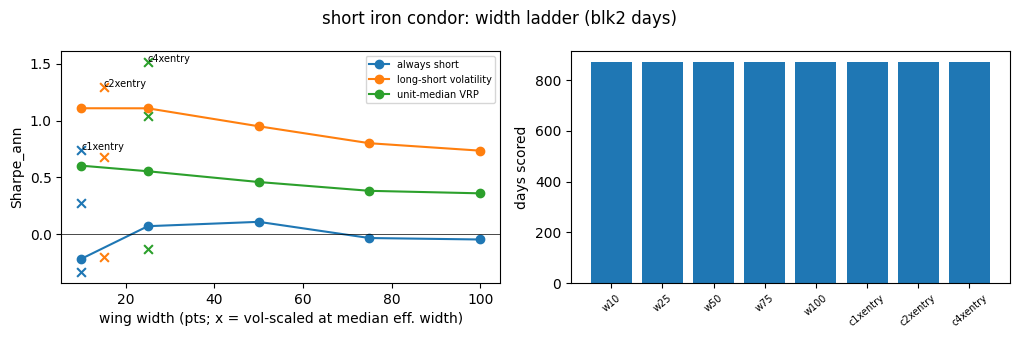

In [9]:
body = atm.reset_index()
close_map = pd.Series(atm["S_close"].to_numpy(), index=pd.to_datetime(atm["expiration"]).values)
close_map.index = pd.to_datetime(close_map.index).tz_localize(None).normalize()

def pick_wings_perday(live_q: pd.DataFrame, body_df: pd.DataFrame, w_row) -> pd.DataFrame:
    # asl.pick_wings with a per-day width; w_row is aligned to body_df rows.
    c = live_q[live_q["cp"] == "C"].copy()
    p = live_q[live_q["cp"] == "P"].copy()
    want_c = body_df[["expiration", "K_c"]].copy()
    want_p = body_df[["expiration", "K_p"]].copy()
    want_c["w"] = np.asarray(w_row, float)
    want_p["w"] = np.asarray(w_row, float)
    c = c.merge(want_c, on="expiration", how="inner")
    p = p.merge(want_p, on="expiration", how="inner")
    c = c[c["strike"].astype(float) >= (c["K_c"] + c["w"])]
    p = p[p["strike"].astype(float) <= (p["K_p"] - p["w"])]
    c["k_gap"] = c["strike"].astype(float) - c["K_c"]
    p["k_gap"] = p["K_p"] - p["strike"].astype(float)
    c_w = c.sort_values(["expiration", "k_gap", "strike"]).groupby("expiration", as_index=False).first()
    p_w = p.sort_values(["expiration", "k_gap", "strike"]).groupby("expiration", as_index=False).first()
    wings = c_w.merge(p_w, on="expiration", suffixes=("_cw", "_pw"))
    wing_cols = ["expiration", "strike_cw", "strike_pw", "mid_cw", "mid_pw"]
    extra = [col for col in ("bid_cw", "ask_cw", "bid_pw", "ask_pw") if col in wings.columns]
    out = body_df.merge(wings[wing_cols + extra], on="expiration", how="inner")
    out["K_c_wing"] = out["strike_cw"].astype(float)
    out["K_p_wing"] = out["strike_pw"].astype(float)
    out["mid_c_wing"] = out["mid_cw"].astype(float)
    out["mid_p_wing"] = out["mid_pw"].astype(float)
    out["entry_body"] = out["entry"].astype(float)
    out["entry_wings"] = out["mid_c_wing"] + out["mid_p_wing"]
    out["entry_ic"] = out["entry_body"] - out["entry_wings"]
    out["width"] = np.minimum(out["K_c_wing"] - out["K_c"], out["K_p"] - out["K_p_wing"])
    return out

def settle_ic(ic_raw: pd.DataFrame, label: str) -> pd.DataFrame:
    print(f"{label}: days with both wings {len(ic_raw)} / body {len(body)} dropped {len(body) - len(ic_raw)}")
    ic = asl.settle_package(ic_raw, close_map)
    ic = ic[np.isfinite(ic["entry_ic"]) & np.isfinite(ic["exit_ic"]) & (ic["width"] > 0)].copy()
    ic["R_long_ic"] = (ic["exit_ic"] - ic["entry_ic"]) / ic["width"]
    ic["R_credit"] = np.where(ic["entry_ic"] > 0, ic["exit_ic"] / ic["entry_ic"] - 1.0, np.nan)
    return ic.set_index("day")

ladder = {}
for w in (10.0, 25.0, 50.0, 75.0, 100.0):
    ladder[f"w{int(w)}"] = settle_ic(asl.pick_wings(live, body, width=w), f"w{int(w)}")
for cmult in (1.0, 2.0, 4.0):
    ladder[f"c{int(cmult)}xentry"] = settle_ic(
        pick_wings_perday(live, body, cmult * body["entry"].to_numpy(float)), f"c{int(cmult)}xentry"
    )

rows = []
grid = {}
for label, ic in ladder.items():
    joined = ic.join(books["blk2"][["signal", "pos", "R"]], how="inner", rsuffix="_strad")
    sizes = asl.rule_sizes(joined)
    common_ic = joined.index.intersection(common)
    grid[label] = {}
    for name in asl.RULE_ORDER:
        rr = asl.rule_row((sizes[name] * joined["R_long_ic"]).loc[common_ic], sizes[name].loc[common_ic])
        rows.append({
            "width": label, "rule": name, "n": rr["n"], "mean": rr["mean"], "std": rr["std"],
            "t_mean": rr["t_mean"], "Sharpe_ann": rr["Sharpe_ann"], "pct_buy": rr["pct_buy"],
            "med_eff_width": float(joined.loc[common_ic, "width"].median()),
            "med_credit": float(joined.loc[common_ic, "entry_ic"].median()),
            "frac_entry_ic_le0": float((ic["entry_ic"] <= 0).mean()),
        })
        grid[label][name] = rr["Sharpe_ann"]

lad_tab = pd.DataFrame(rows).set_index(["width", "rule"])
grid_tab = pd.DataFrame(grid).T[asl.RULE_ORDER]
print("--- condor width ladder, defined-risk R, blk2, common days ---")
print(lad_tab.to_string())
print("--- Sharpe_ann grid ---")
print(grid_tab.to_string())
bench = asl.rule_row((-books["blk2"]["R"]).loc[common], pd.Series(-1.0, index=common))
print(f"benchmark always-short STRADDLE (same days): mean {bench['mean']:.4f} "
      f"t {bench['t_mean']:.2f} Sharpe_ann {bench['Sharpe_ann']:.3f}")
lad_tab.to_csv(OUT / "condor_lab_ladder_blk2.csv")
grid_tab.to_csv(OUT / "condor_lab_sharpe_grid_blk2.csv")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.4))
fixed = [lb for lb in grid_tab.index if lb.startswith("w")]
xs = [float(lb[1:]) for lb in fixed]
for name in asl.RULE_ORDER:
    axes[0].plot(xs, [grid_tab.loc[lb, name] for lb in fixed], marker="o", label=name)
for lb in [x for x in grid_tab.index if x.startswith("c")]:
    mw = lad_tab.xs(lb, level="width")["med_eff_width"].iloc[0]
    axes[0].scatter([mw] * len(asl.RULE_ORDER), grid_tab.loc[lb].to_numpy(), marker="x", s=40)
    axes[0].annotate(lb, (mw, float(grid_tab.loc[lb].max())), fontsize=7)
axes[0].set_xlabel("wing width (pts; x = vol-scaled at median eff. width)")
axes[0].set_ylabel("Sharpe_ann")
axes[0].legend(fontsize=7)
axes[0].axhline(0.0, color="k", lw=0.5)
ns = lad_tab.xs("always short", level="rule")["n"]
axes[1].bar(range(len(ns)), ns.to_numpy())
axes[1].set_xticks(range(len(ns)), ns.index, rotation=40, fontsize=7)
axes[1].set_ylabel("days scored")
fig.suptitle("short iron condor: width ladder (blk2 days)")
fig.tight_layout()
fig.savefig(OUT / "condor_lab_width_ladder.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "condor_lab_width_ladder.png")
display(fig)
plt.close(fig)


## 9. Iron condor diagnostics (w=25, 50)

Body is the 15:30 nearest-OTM package; wings are the nearest live mids
at least $25$ (and $50$) points further OTM, as in the RV–IV notebook.
Defined-risk return $R_{\mathrm{long,ic}}=(\mathrm{exit}_{ic}-\mathrm{entry}_{ic})/\mathrm{width}$.
Four diagnostics, all on blk2 common days:

1. **Wing-cost share** $\mathrm{entry}_{\mathrm{wings}}/\mathrm{entry}_{\mathrm{body}}$
   by year and by $\mathrm{IV}_{30}$ quintile. This is what the tail
   insurance costs, and when.
2. **Coverage**: days with both wings vs body days.
3. **Tail tables**: worst 10 days by straddle unit-median $R'$ with the
   condor unit-median $R'$ beside them, and the reverse. The condor
   loss is capped at $(\mathrm{width}-\mathrm{entry}_{ic})/\mathrm{width}$
   per unit — better tails are **mechanical** (defined risk), not alpha.
4. **IR** of condor unit-median against the straddle always-short and
   straddle unit-median books: active $R^a=R^{ic}-R^{\mathrm{bench}}$,
   `te_daily` $=\mathrm{sd}(R^a)$, $\mathrm{IR}_{ann}=\bar R^a/\mathrm{sd}\times\sqrt{252}$,
   $t=\bar R^a/\mathrm{sd}\times\sqrt{n}$.

Condor sizes follow the RV–IV §16 convention (unit-median leverage from
the expanding median on the condor-day frame); straddle sizes are the
§5 full-book sizes. Cumulative $R'$ is a non-compounded sum.

In [10]:
body = atm.reset_index()
close_map = pd.Series(atm["S_close"].to_numpy(), index=pd.to_datetime(atm["expiration"]).values)
close_map.index = pd.to_datetime(close_map.index).tz_localize(None).normalize()

def build_condor(width: float) -> pd.DataFrame:
    ic = asl.pick_wings(live, body, width=width)
    n_body, n_ic = len(body), len(ic)
    ic = asl.settle_package(ic, close_map)
    ic = ic[np.isfinite(ic["entry_ic"]) & np.isfinite(ic["exit_ic"]) & (ic["width"] > 0)].copy()
    ic["R_long_ic"] = (ic["exit_ic"] - ic["entry_ic"]) / ic["width"]
    ic["wing_share"] = ic["entry_wings"] / ic["entry_body"]
    ic["day"] = pd.to_datetime(ic["et_c"]).dt.tz_convert("America/New_York").dt.normalize().dt.tz_localize(None)
    ic = ic.set_index("day").sort_index()
    print(f"width {width}: days with both wings {n_ic} / body {n_body} dropped {n_body - n_ic}")
    return ic

ics = {w: build_condor(w) for w in (25.0, 50.0)}

cov = pd.DataFrame({
    f"w{int(w)}": {"days_with_wings": len(ic), "body_days": len(body), "dropped": len(body) - len(ic)}
    for w, ic in ics.items()
}).T
print("coverage")
print(cov.to_string())
cov.to_csv(OUT / "condor_lab_diag_coverage.csv")

share_tabs = {}
for w, ic in ics.items():
    by_year = ic["wing_share"].groupby(ic.index.year).median()
    q5 = pd.qcut(ic["iv_30"], 5, labels=[f"Q{i}" for i in range(1, 6)])
    by_iv = ic["wing_share"].groupby(q5, observed=True).median()
    share_tabs[f"w{int(w)}_year"] = by_year
    share_tabs[f"w{int(w)}_iv30q"] = by_iv
    print(f"wing-cost share entry_wings/entry_body, width {int(w)}: median {float(ic['wing_share'].median()):.4f}")
    print("by year"); print(by_year.to_string())
    print("by IV30 quintile"); print(by_iv.to_string())
pd.DataFrame(share_tabs).to_csv(OUT / "condor_lab_diag_wingshare.csv")

blk = books["blk2"]
strad_sizes = asl.rule_sizes(blk)
strad_um = (strad_sizes["unit-median VRP"] * blk["R"]).loc[common]
strad_as = (-blk["R"]).loc[common]

cond_um = {}
for w, ic in ics.items():
    joined = ic.join(blk[["signal", "pos", "R"]], how="inner", rsuffix="_strad")
    sizes = asl.rule_sizes(joined)
    idx = joined.index.intersection(common)
    cond_um[w] = (sizes["unit-median VRP"] * joined["R_long_ic"]).loc[idx]

ir_rows = {}
for w in ics:
    ir_rows[f"IC-UM w{int(w)} vs straddle AS"] = asl.information_ratio(cond_um[w], strad_as)
    ir_rows[f"IC-UM w{int(w)} vs straddle UM"] = asl.information_ratio(cond_um[w], strad_um)
ir_tab = pd.DataFrame(ir_rows).T
print("IR of condor unit-median vs straddle benchmarks")
print(ir_tab.to_string())
ir_tab.to_csv(OUT / "condor_lab_diag_ir.csv")

joint = strad_um.index.intersection(cond_um[25.0].index).intersection(cond_um[50.0].index)
tails = pd.DataFrame({
    "straddle UM": strad_um.loc[joint],
    "IC-UM w25": cond_um[25.0].loc[joint],
    "IC-UM w50": cond_um[50.0].loc[joint],
})
worst_strad = tails.nsmallest(10, "straddle UM")
worst_ic25 = tails.nsmallest(10, "IC-UM w25")
print("worst 10 days by straddle UM R'")
print(worst_strad.to_string())
print("worst 10 days by IC-UM w25 R'")
print(worst_ic25.to_string())
worst_strad.to_csv(OUT / "condor_lab_diag_tails_straddle.csv")
worst_ic25.to_csv(OUT / "condor_lab_diag_tails_ic25.csv")


width 25.0: days with both wings 1291 / body 1291 dropped 0


width 50.0: days with both wings 1291 / body 1291 dropped 0
coverage
     days_with_wings  body_days  dropped
w25             1291       1291        0
w50             1291       1291        0
wing-cost share entry_wings/entry_body, width 25: median 0.0403
by year
day
2020    0.044064
2021    0.034783
2022    0.054515
2023    0.030406
2024    0.040757
2025    0.054424
by IV30 quintile
iv_30
Q1    0.032258
Q2    0.032565
Q3    0.037348
Q4    0.045978
Q5    0.114427
wing-cost share entry_wings/entry_body, width 50: median 0.0144
by year
day
2020    0.013715
2021    0.016949
2022    0.010178
2023    0.013514
2024    0.014707
2025    0.017778
by IV30 quintile
iv_30
Q1    0.018692
Q2    0.013986
Q3    0.012270
Q4    0.010899
Q5    0.016469
IR of condor unit-median vs straddle benchmarks
                                   n  mean_active  te_daily     te_ann    IR_ann  t_active  corr_to_bench
IC-UM w25 vs straddle AS  871.000000    -0.005507  1.139593  18.090479 -0.076707 -0.142607       0.155

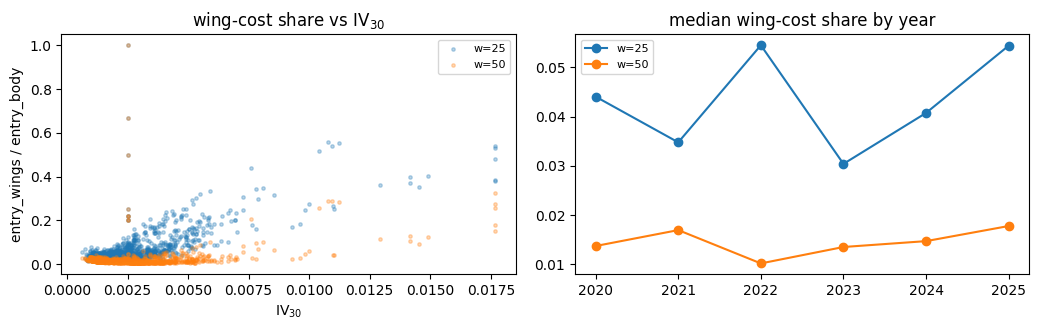

saved C:\Users\james\CC Allowed\harxhar-0dte-professor\results\atm_straddle_0dte_1530\condor_lab_cum.png


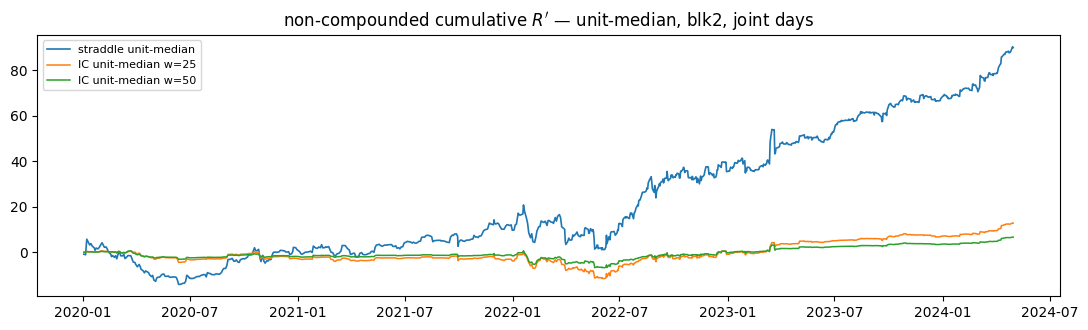

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.4))
for w, ic in ics.items():
    axes[0].scatter(ic["iv_30"], ic["wing_share"], s=6, alpha=0.3, label=f"w={int(w)}")
axes[0].set_xlabel(r"$\mathrm{IV}_{30}$")
axes[0].set_ylabel("entry_wings / entry_body")
axes[0].set_title("wing-cost share vs $\\mathrm{IV}_{30}$")
axes[0].legend(fontsize=8)
for w, ic in ics.items():
    by_year = ic["wing_share"].groupby(ic.index.year).median()
    axes[1].plot(by_year.index, by_year.values, marker="o", label=f"w={int(w)}")
axes[1].set_title("median wing-cost share by year")
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "condor_lab_diagnostics.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(joint, strad_um.loc[joint].cumsum().values, label="straddle unit-median", lw=1.2)
for w in ics:
    ax.plot(joint, cond_um[w].loc[joint].cumsum().values, label=f"IC unit-median w={int(w)}", lw=1.1)
ax.set_title("non-compounded cumulative $R'$ — unit-median, blk2, joint days")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "condor_lab_cum.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "condor_lab_cum.png")
display(fig)
plt.close(fig)


## 10. Strangle-body condors and per-side attribution

§16 of the RV–IV notebook prices the condor around the straddle body.
Here the body is a **strangle**: the next listed strike above the
nearest-OTM call and below the nearest-OTM put, from the same 15:30
live mids (one step on the actual grid — $5$ points on $99.6\%$ of
days, never a fixed offset). Wings are `asl.pick_wings` measured from
the strangle legs, widths $25$ and $50$. Defined-risk return is
unchanged,
$R_{\mathrm{long,ic}}=(\mathrm{exit}_{ic}-\mathrm{entry}_{ic})/\mathrm{width}$,
so the paper's $q$ rules apply as-is; blk2 signal, common days.

**Per-side split** ($w=25$, unit-median $q$). Each side is its own
vertical: $R_{\mathrm{call}}=\big[(\mathrm{pay}_c-\mathrm{pay}_{cw})-(\mathrm{mid}_c-\mathrm{mid}_{cw})\big]/\mathrm{width}$,
same for the put side, so
$R_{\mathrm{call}}+R_{\mathrm{put}}=R_{\mathrm{long,ic}}$ exactly
(same denominator). $R'_{\mathrm{side}}=q\,R_{\mathrm{side}}$ answers
two questions: which spread earns the short-book mean, and which
spread bleeds on the worst-decile days.

In [12]:
close_map = pd.Series(atm["S_close"].to_numpy(), index=pd.to_datetime(atm["expiration"]).values)
close_map.index = pd.to_datetime(close_map.index).tz_localize(None).normalize()
body_straddle = atm.reset_index()

def pick_strangle_body(live, atm_body):
    c = live[live["cp"] == "C"].copy()
    p = live[live["cp"] == "P"].copy()
    want = atm_body[["expiration", "day", "K_c", "K_p", "S"]].copy()
    c = c.merge(want[["expiration", "K_c"]], on="expiration", how="inner")
    p = p.merge(want[["expiration", "K_p"]], on="expiration", how="inner")
    c = c[c["strike"].astype(float) > c["K_c"]]
    p = p[p["strike"].astype(float) < p["K_p"]]
    c["k_gap"] = c["strike"].astype(float) - c["K_c"]
    p["k_gap"] = p["K_p"] - p["strike"].astype(float)
    c2 = c.sort_values(["expiration", "k_gap", "strike"]).groupby("expiration", as_index=False).first()
    p2 = p.sort_values(["expiration", "k_gap", "strike"]).groupby("expiration", as_index=False).first()
    legs = c2.merge(p2, on="expiration", suffixes=("_c", "_p"))
    out = want.merge(legs[["expiration", "strike_c", "strike_p", "mid_c", "mid_p"]],
                     on="expiration", how="inner", suffixes=("_atm", ""))
    out = out.rename(columns={"K_c": "K_c_atm", "K_p": "K_p_atm"})
    out["K_c"] = out["strike_c"].astype(float)
    out["K_p"] = out["strike_p"].astype(float)
    out["entry"] = out["mid_c"].astype(float) + out["mid_p"].astype(float)
    out["step_c"] = out["K_c"] - out["K_c_atm"]
    out["step_p"] = out["K_p_atm"] - out["K_p"]
    return out

body_strangle = pick_strangle_body(live, body_straddle)
print(f"strangle legs {len(body_strangle)} / body {len(body_straddle)}; "
      f"call step 5 on {float((body_strangle['step_c'] == 5).mean()):.1%} of days")

def score_ic(body, width, label):
    ic = asl.pick_wings(live, body, width=width)
    print(f"{label} width {width}: days with both wings {len(ic)} / body {len(body)}")
    ic = asl.settle_package(ic, close_map)
    ic = ic[np.isfinite(ic["entry_ic"]) & np.isfinite(ic["exit_ic"]) & (ic["width"] > 0)].copy()
    ic["R_long_ic"] = (ic["exit_ic"] - ic["entry_ic"]) / ic["width"]
    return ic.set_index("day").sort_index()

RULES = ["always short", "long-short volatility", "unit-median VRP"]
KEEP = ["n", "mean", "t_mean", "Sharpe_ann", "pct_buy"]
sg_tabs, sg_frames = {}, {}
for label, body in (("straddle", body_straddle), ("strangle", body_strangle)):
    for w in (25.0, 50.0):
        ic = score_ic(body, w, label)
        joined = ic.join(books["blk2"][["signal", "pos", "R"]], how="inner", rsuffix="_strad")
        sizes = asl.rule_sizes(joined)
        common_ic = joined.index.intersection(common)
        tab = pd.DataFrame({
            name: asl.rule_row((sizes[name] * joined["R_long_ic"]).loc[common_ic],
                               sizes[name].loc[common_ic])
            for name in RULES
        }).T
        sg_tabs[(label, int(w))] = tab
        sg_frames[(label, int(w))] = (joined, sizes, common_ic)
        tab.to_csv(OUT / f"condor_lab_strangle_rules_{label}_w{int(w)}.csv")
for w in (25, 50):
    print(f"--- defined-risk R, blk2, width {w}: straddle vs strangle body ---")
    print(pd.concat({lb: sg_tabs[(lb, w)][KEEP] for lb in ("straddle", "strangle")},
                    names=["body", "rule"]).to_string())


strangle legs 1291 / body 1291; call step 5 on 99.6% of days


straddle width 25.0: days with both wings 1291 / body 1291


straddle width 50.0: days with both wings 1291 / body 1291


strangle width 25.0: days with both wings 1291 / body 1291


strangle width 50.0: days with both wings 1291 / body 1291
--- defined-risk R, blk2, width 25: straddle vs strangle body ---
                                         n      mean    t_mean  Sharpe_ann    pct_buy
body     rule                                                                        
straddle always short           871.000000  0.001076  0.133792    0.071965   0.000000
         long-short volatility  871.000000  0.016519  2.058810    1.107408  38.920781
         unit-median VRP        871.000000  0.014626  1.030863    0.554488  38.920781
strangle always short           871.000000  0.005019  0.729201    0.392228   0.000000
         long-short volatility  871.000000  0.013294  1.934850    1.040731  38.920781
         unit-median VRP        871.000000  0.012867  0.973115    0.523426  38.920781
--- defined-risk R, blk2, width 50: straddle vs strangle body ---
                                         n      mean    t_mean  Sharpe_ann    pct_buy
body     rule                      

per-side attribution, w=25, unit-median R'
                                     n      mean         t  share_of_total
body     side scope                                                       
straddle call all           871.000000  0.012067  0.910532        0.825013
              worst-decile   88.000000 -0.299439 -3.127772        0.381738
         put  all           871.000000  0.002559  0.183166        0.174987
              worst-decile   88.000000 -0.484971 -5.041375        0.618262
strangle call all           871.000000  0.008583  0.789074        0.667031
              worst-decile   88.000000 -0.306279 -3.775112        0.416870
         put  all           871.000000  0.004284  0.362610        0.332969
              worst-decile   88.000000 -0.428432 -4.972415        0.583130


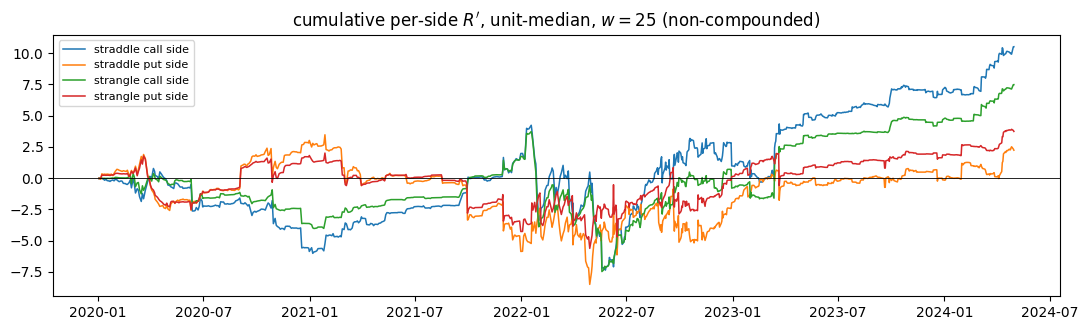

In [13]:
side_rows, side_cum = {}, {}
for label in ("straddle", "strangle"):
    joined, sizes, common_ic = sg_frames[(label, 25)]
    j = joined.loc[common_ic].copy()
    q = sizes["unit-median VRP"].loc[common_ic]
    j["R_call"] = ((j["pay_c"] - j["pay_c_wing"]) - (j["mid_c"].astype(float) - j["mid_c_wing"])) / j["width"]
    j["R_put"] = ((j["pay_p"] - j["pay_p_wing"]) - (j["mid_p"].astype(float) - j["mid_p_wing"])) / j["width"]
    assert (j["R_call"] + j["R_put"] - j["R_long_ic"]).abs().max() < 1e-10
    rp_tot = q * j["R_long_ic"]
    worst = rp_tot <= rp_tot.quantile(0.10)
    for side in ("R_call", "R_put"):
        rp = q * j[side]
        side_cum[(label, side)] = rp.cumsum()
        for scope, mask in (("all", rp_tot.notna()), ("worst-decile", worst)):
            x = rp[mask]
            mu, sd, n = float(x.mean()), float(x.std(ddof=1)), int(len(x))
            side_rows[(label, side.replace("R_", ""), scope)] = {
                "n": n, "mean": mu,
                "t": mu / sd * np.sqrt(n) if sd > 0 else np.nan,
                "share_of_total": mu / float(rp_tot[mask].mean()),
            }
side_tab = pd.DataFrame(side_rows).T
side_tab.index.names = ["body", "side", "scope"]
print("per-side attribution, w=25, unit-median R'")
print(side_tab.to_string())
side_tab.to_csv(OUT / "condor_lab_strangle_per_side_w25.csv")

fig, ax = plt.subplots(figsize=(11, 3.4))
for (label, side), cum in side_cum.items():
    ax.plot(cum.index, cum.values, lw=1.1,
            label=f"{label} {side.replace('R_', '')} side")
ax.axhline(0, color="k", lw=0.6)
ax.set_title("cumulative per-side $R'$, unit-median, $w=25$ (non-compounded)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT / "condor_lab_strangle.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)


## 11. Ensembles on the iron condor (defined-risk $R$)

One question: do the §5 ensemble positions transfer from the straddle
to the defined-risk condor instrument? The positions $q_t$ (mean-$s$
sign, majority vote, EW unit-median $q$, causal spectral PC1 sign /
unit-median, and the blk2 single-model benchmarks) are built once on
the common days exactly as in §5 and are not refit. Only the
instrument swaps: wings are the nearest live mids at least $w$ points
further OTM ($w=25,50$; the RV–IV notebook's §16 construction) and
$R_{\mathrm{long,ic}}=(\mathrm{exit}_{ic}-\mathrm{entry}_{ic})/\mathrm{width}$,
so the paper's $q$ rules apply unchanged.

Each width prints two tables on the same day set $D_w$ (common days
with both wings): the condor book, and the same $q$ on the straddle
$R$. The mirror isolates instrument transfer from day-set drift; with
full wing coverage $D_w$ equals the common days and the drift is zero.

Caveats. Defined-risk $R$ divides by width, not premium: losses are
capped by construction and the denominator differs across instruments,
so Sharpe moves are partly tail/denominator effects, not signal
quality. The blk2 unit-median row uses §5's leverage (expanding median
on the common days), so it can differ slightly from the RV–IV §16 row,
which recomputes leverage on condor-coverage days.

In [14]:
qs = {
    "mean-s then sign": np.sign(sig.mean(axis=1)).replace(0.0, -1.0),
    "majority vote": np.sign(pos.sum(axis=1)).replace(0.0, -1.0),
    "EW unit-median q": um.mean(axis=1),
    "spectral PC1 sign": q_pc1,
    "spectral PC1 unit-median": q_pc1_um,
    "blk2 unit-median": blk_sizes["unit-median VRP"].loc[common],
    "blk2 always short": pd.Series(-1.0, index=common),
}
body = atm.reset_index()
_exp = pd.to_datetime(atm["expiration"])
if getattr(_exp.dt, "tz", None) is not None:
    _exp = _exp.dt.tz_convert("America/New_York").dt.tz_localize(None)
close_map = pd.Series(atm["S_close"].to_numpy(), index=_exp.dt.normalize().values)

def bridge_table(r, D):
    return pd.DataFrame(
        {name: asl.rule_row(q.loc[D] * r.loc[D], q.loc[D]) for name, q in qs.items()}
    ).T

SHOW = ["n", "mean", "std", "t_mean", "Sharpe_ann", "pct_buy"]
tabs = {}
for w in (25.0, 50.0):
    ic = asl.pick_wings(live, body, width=w)
    n_wings = len(ic)
    ic = asl.settle_package(ic, close_map)
    ic = ic[np.isfinite(ic["entry_ic"]) & np.isfinite(ic["exit_ic"]) & (ic["width"] > 0)].copy()
    ic["R_long_ic"] = (ic["exit_ic"] - ic["entry_ic"]) / ic["width"]
    ic = ic.set_index("day")
    D = ic.index.intersection(common)
    print(f"width {int(w)}: both wings {n_wings} / {len(body)} body days; "
          f"scored D = common & coverage = {len(D)} / {len(common)} common")
    print(f"width {int(w)} frac entry_ic<=0 = {float((ic['entry_ic'] <= 0).mean()):.2%}")
    tabs[(int(w), "condor")] = bridge_table(ic["R_long_ic"], D)
    tabs[(int(w), "straddle same days")] = bridge_table(R, D)
    print(f"--- ensembles on iron condor w={int(w)}, defined-risk R ---")
    print(tabs[(int(w), "condor")][SHOW].to_string())
    print(f"--- same q on straddle R, same {len(D)} days ---")
    print(tabs[(int(w), "straddle same days")][SHOW].to_string())
pd.concat(tabs, names=["width", "instrument", "rule"]).to_csv(OUT / "condor_lab_ensemble.csv")
print("saved", OUT / "condor_lab_ensemble.csv")


width 25: both wings 1291 / 1291 body days; scored D = common & coverage = 871 / 871 common
width 25 frac entry_ic<=0 = 0.08%
--- ensembles on iron condor w=25, defined-risk R ---
                                   n      mean       std    t_mean  Sharpe_ann    pct_buy
mean-s then sign          871.000000  0.015383  0.236867  1.916709    1.030973  35.820896
majority vote             871.000000  0.015370  0.236868  1.915034    1.030072  35.476464
EW unit-median q          871.000000  0.016256  0.391116  1.226611    0.659778  36.165327
spectral PC1 sign         871.000000  0.012175  0.237054  1.515762    0.815309  23.880597
spectral PC1 unit-median  871.000000 -0.001507  0.289286 -0.153734   -0.082692  23.880597
blk2 unit-median          871.000000  0.014626  0.418726  1.030863    0.554488  38.920781
blk2 always short         871.000000  0.001076  0.237364  0.133792    0.071965   0.000000
--- same q on straddle R, same 871 days ---
                                   n      mean       std

width 50: both wings 1291 / 1291 body days; scored D = common & coverage = 871 / 871 common
width 50 frac entry_ic<=0 = 0.08%
--- ensembles on iron condor w=50, defined-risk R ---
                                   n      mean       std    t_mean  Sharpe_ann    pct_buy
mean-s then sign          871.000000  0.009084  0.140651  1.906058    1.025244  35.820896
majority vote             871.000000  0.009104  0.140649  1.910212    1.027478  35.476464
EW unit-median q          871.000000  0.011531  0.234125  1.453485    0.781811  36.165327
spectral PC1 sign         871.000000  0.007308  0.140754  1.532379    0.824247  23.880597
spectral PC1 unit-median  871.000000  0.001789  0.185483  0.284694    0.153133  23.880597
blk2 unit-median          871.000000  0.007542  0.260284  0.855158    0.459979  38.920781
blk2 always short         871.000000  0.000978  0.140941  0.204774    0.110145   0.000000
--- same q on straddle R, same 871 days ---
                                   n      mean       std

## 12. Fill sensitivity (quoted-spread $\lambda$-fills)

A condor has four legs, a straddle two: quoted-spread cost is the
standing objection to any condor result. Fill model, per leg,

$$\mathrm{fill} = \mathrm{mid} + \sigma\,\lambda\,\tfrac{\mathrm{ask}-\mathrm{bid}}{2},
\qquad \sigma=+1\ \text{bought},\ \sigma=-1\ \text{sold},\qquad
\lambda\in\{0,\tfrac12,1\}.$$

$\lambda=0$ is the mid-fill book; $\lambda=1$ fills every short leg at
the bid and every long leg at the ask (the lib's
`crossed_premium_return` at the straddle). Exit is cash settlement at
the official close — no exit spread. The signal $s$ is untouched:
fills change $R$, not $s$, so positions are identical across
$\lambda$ and the tables isolate pure fill cost. Straddle $R$ keeps
the entry denominator (now the filled entry); condor $R$ keeps the
width denominator, so its cost enters linearly:
$R'=qR_{\mathrm{long,ic}} - |q|\,\lambda\,H/\mathrm{width}$ with $H$
the sum of the four half-spreads.

Quote hygiene: sold legs require $\mathrm{bid}>0$; bought wing legs
allow a zero bid (a legitimate deep-OTM quote state — the buy fills at
the ask side). Zero-bid wings are the norm, not the exception (w=50
call wing: bid $\le 0$ on 783 of 871 days), which is exactly why wing
spreads are proportionally enormous while body spreads are tight. The
scored set is the quoted subset of the common days (867 of 871); the
$\lambda=0$ rows therefore differ slightly from the §5/§7 tables — the
four dropped days were profitable shorts.

$\lambda=1$ is a worst-case quoted fill, not a market-impact model;
real fills on a four-leg package sit between the marks.

hygiene body call      n=871 missing=0 bid<=0=3 crossed=0 usable=868 (strict bid>0: 868)
hygiene body put       n=871 missing=0 bid<=0=3 crossed=0 usable=868 (strict bid>0: 868)
straddle: common=871 scored=867
--- straddle, lambda-fill, blk2 ---
                                  n      mean    t_mean  Sharpe_ann
lam=0.0 always short     867.000000  0.015612  0.407718    0.219812
        unit-median VRP  867.000000  0.092229  2.172740    1.171382
lam=0.5 always short     867.000000 -0.001348 -0.034549   -0.018626
        unit-median VRP  867.000000  0.077059  1.809566    0.975585
lam=1.0 always short     867.000000 -0.019103 -0.480457   -0.259027
        unit-median VRP  867.000000  0.061729  1.443711    0.778343


width 25.0: days with both wings 1291 / body 1291
hygiene body C (w25)   n=871 missing=0 bid<=0=3 crossed=0 usable=868 (strict bid>0: 868)
hygiene body P (w25)   n=871 missing=0 bid<=0=3 crossed=0 usable=868 (strict bid>0: 868)
hygiene wing C (w25)   n=871 missing=0 bid<=0=421 crossed=0 usable=871 (strict bid>0: 450)
hygiene wing P (w25)   n=871 missing=0 bid<=0=128 crossed=0 usable=871 (strict bid>0: 743)
condor w25: scored=867
--- iron condor w=25, defined-risk R, lambda-fill, blk2 ---
                                  n      mean    t_mean  Sharpe_ann
lam=0.0 always short     867.000000  0.001064  0.131650    0.070976
        unit-median VRP  867.000000  0.014650  1.027843    0.554138
lam=0.5 always short     867.000000 -0.005517 -0.679574   -0.366376
        unit-median VRP  867.000000  0.006505  0.454824    0.245208
lam=1.0 always short     867.000000 -0.012097 -1.478608   -0.797157
        unit-median VRP  867.000000 -0.001640 -0.114106   -0.061517


width 50.0: days with both wings 1291 / body 1291
hygiene body C (w50)   n=871 missing=0 bid<=0=3 crossed=0 usable=868 (strict bid>0: 868)
hygiene body P (w50)   n=871 missing=0 bid<=0=3 crossed=0 usable=868 (strict bid>0: 868)
hygiene wing C (w50)   n=871 missing=0 bid<=0=783 crossed=0 usable=871 (strict bid>0: 88)
hygiene wing P (w50)   n=871 missing=0 bid<=0=592 crossed=0 usable=871 (strict bid>0: 279)
condor w50: scored=867
--- iron condor w=50, defined-risk R, lambda-fill, blk2 ---
                                  n      mean    t_mean  Sharpe_ann
lam=0.0 always short     867.000000  0.000974  0.202970    0.109427
        unit-median VRP  867.000000  0.007555  0.852728    0.459728
lam=0.5 always short     867.000000 -0.002070 -0.428247   -0.230880
        unit-median VRP  867.000000  0.003844  0.432788    0.233328
lam=1.0 always short     867.000000 -0.005114 -1.048186   -0.565105
        unit-median VRP  867.000000  0.000132  0.014822    0.007991
--- Sharpe erosion: Sharpe(lam=1

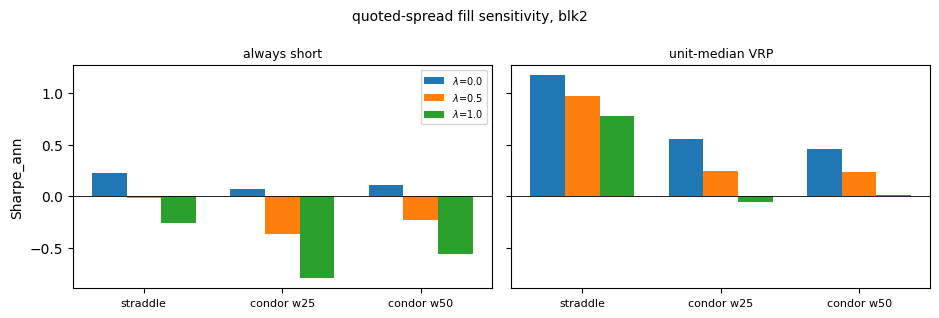

In [15]:
def _tc_leg_ok(bid, ask, sold):
    b = pd.to_numeric(bid, errors="coerce")
    a = pd.to_numeric(ask, errors="coerce")
    base = np.isfinite(b) & np.isfinite(a) & (a >= b) & (b >= 0)
    return base & (b > 0) if sold else base

def _tc_hygiene(df, b, a, label, sold):
    bb, aa = pd.to_numeric(df[b], errors="coerce"), pd.to_numeric(df[a], errors="coerce")
    ok = _tc_leg_ok(bb, aa, sold)
    print(f"hygiene {label:14s} n={len(df)} missing={int((~np.isfinite(bb) | ~np.isfinite(aa)).sum())} "
          f"bid<=0={int((np.isfinite(bb) & (bb <= 0)).sum())} "
          f"crossed={int((np.isfinite(bb) & np.isfinite(aa) & (bb > aa)).sum())} "
          f"usable={int(ok.sum())} (strict bid>0: {int(_tc_leg_ok(bb, aa, True).sum())})")
    return ok

px = books["blk2"]
tc_sizes = asl.rule_sizes(px)
TC_RULES = ["always short", "unit-median VRP"]
TC_LAMS = [0.0, 0.5, 1.0]

ok_c = _tc_hygiene(px, "bid_c", "ask_c", "body call", sold=True)
ok_p = _tc_hygiene(px, "bid_p", "ask_p", "body put", sold=True)
idx_s = common.intersection(px.index[ok_c & ok_p])
print(f"straddle: common={len(common)} scored={len(idx_s)}")
h_strad = (px["ask_c"] - px["bid_c"]) / 2.0 + (px["ask_p"] - px["bid_p"]) / 2.0
tc_spreads = {
    "body call": float(((px["ask_c"] - px["bid_c"]) / px["mid_c"]).loc[idx_s].median()),
    "body put": float(((px["ask_p"] - px["bid_p"]) / px["mid_p"]).loc[idx_s].median()),
}
rows = {}
for lam in TC_LAMS:
    for rule in TC_RULES:
        q = tc_sizes[rule]
        entry_fill = px["entry"] + np.sign(q) * lam * h_strad
        rp = q * (px["exit"] / entry_fill - 1.0)
        rows[(f"lam={lam}", rule)] = asl.rule_row(rp.loc[idx_s], q.loc[idx_s])
tc_tabs = {"straddle": pd.DataFrame(rows).T[["n", "mean", "t_mean", "Sharpe_ann"]]}
print("--- straddle, lambda-fill, blk2 ---")
print(tc_tabs["straddle"].to_string())
tc_tabs["straddle"].to_csv(OUT / "condor_lab_tcost_straddle.csv")

tc_body = atm.reset_index()
tc_close = pd.Series(atm["S_close"].to_numpy(), index=pd.to_datetime(atm["expiration"]).values)
tc_close.index = pd.to_datetime(tc_close.index).tz_localize(None).normalize()
for w in (25.0, 50.0):
    ic = asl.pick_wings(live, tc_body, width=w)
    print(f"width {w}: days with both wings {len(ic)} / body {len(tc_body)}")
    ic = asl.settle_package(ic, tc_close)
    ic = ic[np.isfinite(ic["entry_ic"]) & np.isfinite(ic["exit_ic"]) & (ic["width"] > 0)].set_index("day")
    joined = ic.join(px[["signal", "pos", "R"]], how="inner", rsuffix="_strad")
    sz = asl.rule_sizes(joined)
    oks = (_tc_hygiene(joined, "bid_c", "ask_c", f"body C (w{int(w)})", sold=True)
           & _tc_hygiene(joined, "bid_p", "ask_p", f"body P (w{int(w)})", sold=True)
           & _tc_hygiene(joined, "bid_cw", "ask_cw", f"wing C (w{int(w)})", sold=False)
           & _tc_hygiene(joined, "bid_pw", "ask_pw", f"wing P (w{int(w)})", sold=False))
    idx = joined.index[oks].intersection(common)
    print(f"condor w{int(w)}: scored={len(idx)}")
    h_tot = ((joined["ask_c"] - joined["bid_c"]) + (joined["ask_p"] - joined["bid_p"])
             + (joined["ask_cw"] - joined["bid_cw"]) + (joined["ask_pw"] - joined["bid_pw"])) / 2.0
    tc_spreads[f"wing call w{int(w)}"] = float(((joined["ask_cw"] - joined["bid_cw"]) / joined["mid_c_wing"]).loc[idx].median())
    tc_spreads[f"wing put w{int(w)}"] = float(((joined["ask_pw"] - joined["bid_pw"]) / joined["mid_p_wing"]).loc[idx].median())
    base = (joined["exit_ic"] - joined["entry_ic"]) / joined["width"]
    rows = {}
    for lam in TC_LAMS:
        for rule in TC_RULES:
            q = sz[rule]
            rp = q * base - q.abs() * lam * h_tot / joined["width"]
            rows[(f"lam={lam}", rule)] = asl.rule_row(rp.loc[idx], q.loc[idx])
    tab = pd.DataFrame(rows).T[["n", "mean", "t_mean", "Sharpe_ann"]]
    print(f"--- iron condor w={int(w)}, defined-risk R, lambda-fill, blk2 ---")
    print(tab.to_string())
    tab.to_csv(OUT / f"condor_lab_tcost_w{int(w)}.csv")
    tc_tabs[f"condor w{int(w)}"] = tab

tc_ero = pd.Series({(inst, rule): tab.loc[("lam=1.0", rule), "Sharpe_ann"] - tab.loc[("lam=0.0", rule), "Sharpe_ann"]
                    for inst, tab in tc_tabs.items() for rule in TC_RULES}).unstack()
print("--- Sharpe erosion: Sharpe(lam=1) - Sharpe(lam=0) ---")
print(tc_ero.to_string())
tc_ero.to_csv(OUT / "condor_lab_tcost_erosion.csv")
tc_sp = pd.Series(tc_spreads, name="median (ask-bid)/mid")
print("--- median relative spread by leg class ---")
print(tc_sp.to_string())
tc_sp.to_csv(OUT / "condor_lab_tcost_spreads.csv")

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2), sharey=True)
xs = np.arange(len(tc_tabs))
for ax, rule in zip(axes, TC_RULES):
    for j, lam in enumerate(TC_LAMS):
        ys = [tc_tabs[k].loc[(f"lam={lam}", rule), "Sharpe_ann"] for k in tc_tabs]
        ax.bar(xs + (j - 1) * 0.25, ys, width=0.25, label=f"$\\lambda$={lam}")
    ax.set_xticks(xs)
    ax.set_xticklabels(list(tc_tabs), fontsize=8)
    ax.set_title(rule, fontsize=9)
    ax.axhline(0, color="k", lw=0.6)
axes[0].set_ylabel("Sharpe_ann")
axes[0].legend(fontsize=7)
fig.suptitle("quoted-spread fill sensitivity, blk2", fontsize=10)
fig.tight_layout()
fig.savefig(OUT / "condor_lab_tcost.png", dpi=120, bbox_inches="tight")
display(fig)
plt.close(fig)


## 13. Paired significance on the headline deltas

The `rule_row` $t$'s test each book's mean against zero. The questions
that matter are *differences*: does book $A$ beat book $B$ on the same
days? Let $d_t = R'^{A}_t - R'^{B}_t$ on the common days of the pair.
Two tests, both stated once and applied to every pair:

- **Newey–West:** $t = \bar d / \widehat{\mathrm{se}}_{NW}(\bar d)$
  with Bartlett kernel and lag $L=\lfloor 1.5\,n^{1/3}\rfloor$.
- **Circular moving-block bootstrap:** block length
  $b=\lceil n^{1/3}\rceil$, $B=2000$, seed $0$, resampling the pair
  jointly. 95% percentile CI on $\bar d$ and on
  $\Delta\mathrm{Sharpe}_{ann}$ (both books' Sharpes recomputed per
  resample, then differenced).

Pairs: (a) condor $w{=}25$ unit-median vs straddle unit-median, same
blk2 $q_t$ both legs (the published straddle-book sizes restricted to
condor days — leverage is *not* refit on the condor subset); (b)
spectral PC1 unit-median vs blk2 unit-median; (c) EW unit-median $q$
vs blk2 unit-median; (d) blk2 unit-median vs always short.

Caveats. In (a) the two returns sit on different denominators
(straddle entry vs condor width), so $\bar d$ is a bookkeeping
comparison of the published book definitions; $\Delta$Sharpe is the
scale-free column. A null here is the expected outcome — nothing in
this lab has beaten blk2 unit-median — these rows say whether the
*gaps* in the ensemble table are distinguishable from noise at all.
`mean_delta_bp` is $\bar d\times 10^4$ per day; `sig_*` flags are 5%
two-sided.

In [16]:
def _nw_t(d):
    n_ = len(d)
    L = int(np.floor(1.5 * n_ ** (1.0 / 3.0)))
    dc = d - d.mean()
    v = float(dc @ dc) / n_
    for lag in range(1, L + 1):
        v += 2.0 * (1.0 - lag / (L + 1.0)) * float(dc[lag:] @ dc[:-lag]) / n_
    return float(d.mean() / np.sqrt(v / n_)), L

def _cmb_idx(n_, B, rng):
    b = int(np.ceil(n_ ** (1.0 / 3.0)))
    nb = int(np.ceil(n_ / b))
    starts = rng.integers(0, n_, size=(B, nb))
    return ((starts[:, :, None] + np.arange(b)[None, None, :]) % n_).reshape(B, nb * b)[:, :n_]

def _sharpe(a, axis=None):
    return a.mean(axis=axis) / a.std(axis=axis, ddof=1) * np.sqrt(252.0)

def pair_row(name, rp, rb, B=2000):
    a = rp.align(rb, join="inner")
    x = a[0].dropna()
    y = a[1].reindex(x.index)
    x, y = x.to_numpy(float), y.to_numpy(float)
    d = x - y
    n_ = len(d)
    t_nw, L = _nw_t(d)
    idx = _cmb_idx(n_, B, np.random.default_rng(0))
    dm = d[idx].mean(axis=1)
    lo_m, hi_m = np.percentile(dm, [2.5, 97.5])
    ds = _sharpe(x[idx], axis=1) - _sharpe(y[idx], axis=1)
    lo_s, hi_s = np.percentile(ds, [2.5, 97.5])
    return {
        "pair": name, "n": n_, "nw_lag": L,
        "block_len": int(np.ceil(n_ ** (1.0 / 3.0))),
        "mean_delta_bp": d.mean() * 1e4, "NW_t": t_nw,
        "boot_lo_bp": lo_m * 1e4, "boot_hi_bp": hi_m * 1e4,
        "dSharpe_ann": _sharpe(x) - _sharpe(y), "dS_lo": lo_s, "dS_hi": hi_s,
        "sig_NW": abs(t_nw) > 1.96,
        "sig_boot_mean": (lo_m > 0) or (hi_m < 0),
        "sig_boot_dS": (lo_s > 0) or (hi_s < 0),
    }

# condor w=25, §16 conventions; blk2 straddle-book UM sizes on both legs
body = atm.reset_index()
close_map = pd.Series(atm["S_close"].to_numpy(), index=pd.to_datetime(atm["expiration"]).values)
close_map.index = pd.to_datetime(close_map.index).tz_localize(None).normalize()
ic25 = asl.pick_wings(live, body, width=25.0)
ic25 = asl.settle_package(ic25, close_map)
ic25 = ic25[np.isfinite(ic25["entry_ic"]) & np.isfinite(ic25["exit_ic"]) & (ic25["width"] > 0)].copy()
ic25["R_long_ic"] = (ic25["exit_ic"] - ic25["entry_ic"]) / ic25["width"]
ic25 = ic25.set_index("day")
common_ic = ic25.index.intersection(common).sort_values()
um_blk2 = blk_sizes["unit-median VRP"]
r_ic_um = um_blk2.loc[common_ic] * ic25["R_long_ic"].loc[common_ic]
print("condor w25 coverage on common days", len(common_ic), "/", len(common))

sig_tab = pd.DataFrame([
    pair_row("condor25 UM - straddle UM (blk2)", r_ic_um, ens["blk2 unit-median (bench)"].loc[common_ic]),
    pair_row("PC1 UM - blk2 UM", ens["spectral PC1 unit-median"], ens["blk2 unit-median (bench)"]),
    pair_row("EW um q - blk2 UM", ens["EW unit-median q"], ens["blk2 unit-median (bench)"]),
    pair_row("blk2 UM - always short", ens["blk2 unit-median (bench)"], ens["always short"]),
]).set_index("pair")
print(sig_tab.to_string(float_format=lambda v: f"{v: .3f}"))
sig_tab.to_csv(OUT / "significance_pairs.csv")
print("saved", OUT / "significance_pairs.csv")


condor w25 coverage on common days 871 / 871


                                    n  nw_lag  block_len  mean_delta_bp   NW_t  boot_lo_bp  boot_hi_bp  dSharpe_ann  dS_lo  dS_hi  sig_NW  sig_boot_mean  sig_boot_dS
pair                                                                                                                                                                 
condor25 UM - straddle UM (blk2)  871      14         10       -887.260 -3.451   -1459.513    -335.953       -0.750 -1.267 -0.232    True           True         True
PC1 UM - blk2 UM                  871      14         10       -693.637 -2.721   -1251.765    -155.249       -0.704 -1.519  0.097    True           True        False
EW um q - blk2 UM                 871      14         10         76.246  0.539    -202.319     380.208        0.294 -0.106  0.722   False          False        False
blk2 UM - always short            871      14         10        832.194  1.832    -184.884    1839.909        1.020 -0.389  2.328   False          False        False
save